# Análisis de datos - Trabajo práctico integrador. Parte 2

## Integrantes

1. Sebastian Biagiola
2. Erlin Rey
3. Jonathan Matias Borda


## Consignas
1. Preprocesamiento y limpieza del dataset:
  * Realizar una limpieza general del dataset, eliminando o corrigiendo datos
inconsistentes o irrelevantes.
  * Realizar el split del dataset (ej: train y test).
  * Identificar y tratar los valores faltantes en el dataset.
  * Detectar y manejar los outliers utilizando técnicas estadísticas o visuales
apropiadas.
  * Escalar y / o normalizar los features.

2. Feature engineering:
  * Crear nuevos features en caso de ser necesario. Justificar.
  * Aplicar técnicas de conversión de variables: codificación, discretización.
  * Analizar el balance/desbalance de clases (en el caso que se trate de un problema de
clasificación).
  * Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

3. Reducción de dimensionalidad
  * Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).
  * Implementar dos técnicas de extracción de features (ej: PCA). Comparar entre sí, y comparar el dataset original con el dataset reducido; evaluar ventajas y desventajas de la reducción.

## DESARROLLO


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
import geopandas as gpd
import missingno as msno
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns

1. Preprocesamiento y limpieza del dataset:
  * Realizar una limpieza general del dataset, eliminando o corrigiendo datos
inconsistentes o irrelevantes.

In [2]:
#Carga del dataset
base_path = 'data'
try:
    path_listings = f"{base_path}listings.csv.gz"
    path_neighbourhoods = f"{base_path}neighbourhoods.csv"
    path_reviews = f"{base_path}reviews.csv.gz"
    path_calendar = f"{base_path}calendar.csv.gz"
    path_geojson = f"{base_path}neighbourhoods.geojson"

    data_base_url = "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2025-01-29/data/"
    data_visualizations_url = "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2025-01-29/visualisations/"
    df_listings= pd.read_csv(data_base_url + "listings.csv.gz", compression='gzip')
    df_reviews = pd.read_csv(data_base_url + "reviews.csv.gz", compression='gzip')
    df_calendar = pd.read_csv(data_base_url + "calendar.csv.gz", compression='gzip')
    gdf_barrios = gpd.read_file(data_visualizations_url + "neighbourhoods.geojson")
    df_barrios_oficiales = pd.read_csv(data_visualizations_url + "neighbourhoods.csv")

    print(" ¡Todos los archivos se han cargado exitosamente desde Google Drive!")

except FileNotFoundError:
    print(" ERROR: No se encontró uno o más archivos. Verifica que la ruta en 'base_path' sea correcta y que los archivos estén en esa carpeta de tu Drive.")

 ¡Todos los archivos se han cargado exitosamente desde Google Drive!


In [3]:
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            35172 non-null  int64  
 1   listing_url                                   35172 non-null  object 
 2   scrape_id                                     35172 non-null  int64  
 3   last_scraped                                  35172 non-null  object 
 4   source                                        35172 non-null  object 
 5   name                                          35172 non-null  object 
 6   description                                   34299 non-null  object 
 7   neighborhood_overview                         16588 non-null  object 
 8   picture_url                                   35171 non-null  object 
 9   host_id                                       35172 non-null 

In [4]:
# --- 1. Conversión de Columnas de Fecha ---

cols_fecha = ['last_scraped', 'host_since', 'first_review', 'last_review']
for col in cols_fecha:
    # Se verifica si la columna existe antes de intentar la conversión
    if col in df_listings.columns:
        df_listings[col] = pd.to_datetime(df_listings[col], errors='coerce')

print("Conversión de columnas de fecha completada.")

# --- 2. Limpieza y Conversión de Columnas Numéricas ---
# Limpieza de la columna de precio
if 'price' in df_listings.columns:
    df_listings['price'] = df_listings['price'].replace({'\$': '', ',': ''}, regex=True)
    df_listings['price'] = pd.to_numeric(df_listings['price'], errors='coerce')

# Limpieza de columnas de porcentajes
cols_porcentaje = ['host_response_rate', 'host_acceptance_rate']
for col in cols_porcentaje:
    if col in df_listings.columns:
        # Se elimina el '%' y se convierte a float, dividiendo por 100
        df_listings[col] = df_listings[col].str.replace('%', '', regex=False)
        df_listings[col] = pd.to_numeric(df_listings[col], errors='coerce') / 100

print("Conversión de columnas numéricas completada.")

# --- 3. Conversión de Columnas Booleanas ---
# 't' representa True, 'f' representa False. Usamos un mapa para la conversión.
mapa_booleano = {'t': True, 'f': False}
cols_booleano = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
                 'has_availability', 'instant_bookable']

for col in cols_booleano:
    if col in df_listings.columns:
        # Se aplica el mapa y LUEGO se convierte explícitamente al tipo 'boolean' de pandas, que admite nulos
        series_mapeada = df_listings[col].map(mapa_booleano)
        df_listings[col] = series_mapeada.astype('boolean')

print("Conversión de columnas booleanas completada.")

# --- Verificación Final ---
# Mostramos la información de las columnas modificadas para verificar el cambio.
print("\n--- Verificando los nuevos tipos de datos ---")
columnas_modificadas = [col for col in cols_fecha + ['price'] + cols_porcentaje + cols_booleano if col in df_listings.columns]
df_listings.info()

Conversión de columnas de fecha completada.
Conversión de columnas numéricas completada.
Conversión de columnas booleanas completada.

--- Verificando los nuevos tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            35172 non-null  int64         
 1   listing_url                                   35172 non-null  object        
 2   scrape_id                                     35172 non-null  int64         
 3   last_scraped                                  35172 non-null  datetime64[ns]
 4   source                                        35172 non-null  object        
 5   name                                          35172 non-null  object        
 6   description                                   342

Análisis de la Estructura y Composición del DataFrame (Post-Conversión)

Una vez procesados los datos y ajustados los tipos de datos, se utiliza el método `.info()` para realizar un análisis técnico de la estructura final del DataFrame `df_listings`.

El resultado indica que el conjunto de datos se compone de **35,172 observaciones** (filas) y **79 características** (columnas). Tras el proceso de conversión, la composición de los tipos de datos (`Dtype`) es la siguiente:

* **5 columnas de tipo `boolean`**.
* **4 columnas de tipo `datetime64[ns]`** (fechas).
* **47 columnas numéricas** (23 `float64` y 24 `int64`).
* **23 columnas de tipo `object`** (texto).

Esta estructura, con los tipos correctamente asignados, es ahora adecuada para el análisis numérico, temporal y categórico.

La columna `Non-Null Count` todavía revela la presencia de **datos faltantes** en varias columnas clave, lo cual es un hallazgo fundamental para las etapas posteriores. Se observa una cantidad significativa de nulos en columnas descriptivas como `neighborhood_overview` y `host_about`, así como en variables importantes como `price`. Notablemente, columnas como `neighbourhood_group_cleansed` y `calendar_updated` se encuentran completamente vacías y, por lo tanto, pueden ser descartadas.


Analizamos los datasets de calendar y reviews busacando elementos que puedan enriquecer nuestro DS para genrar un unico punto de nformación antes de proceder con los splits y el resto de trabajo a realizar. Se analiza incluir analisis de precios recientes de calendar y sentimeintos de reviews

In [5]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12837777 entries, 0 to 12837776
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  float64
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 685.6+ MB


### Análisis Estructural del Dataset del Calendario


* **Escala del Dataset:** La característica más destacada de este conjunto de datos es su **gran escala**, con más de **12.8 millones de registros**. Cada registro representa el estado de un alojamiento (`listing_id`) para una fecha (`date`) específica durante el transcurso de un año, detallando su disponibilidad y precio.

* **Composición y Tipos de Datos:** El DataFrame consta de 7 columnas. El análisis de los tipos de datos (`Dtype`) revela que varias columnas clave fueron cargadas con un formato incorrecto, lo que requiere un preprocesamiento antes de su utilización:
    * La columna `date`, debe ser convertida a `datetime` para permitir análisis temporales.
    * La columna `available`, de tipo `object`, contiene indicadores de disponibilidad (probablemente 't' y 'f') y debe ser convertida a un tipo `boolean`.
    * La columna `price`,  contiene el precio como texto (incluyendo símbolos de moneda) y requiere una limpieza y conversión a un tipo numérico (`float64`) para poder realizar cálculos.

En conclusión, este análisis inicial revela que el dataset del calendario es una fuente de datos extremadamente rica y granular, pero su gran volumen y los tipos de datos incorrectos presentan desafíos técnicos que deben ser abordados. La conversión de tipos es el primer paso indispensable para poder explotar la información sobre precios dinámicos y disponibilidad que contiene.

In [6]:

print("Iniciando limpieza y feature engineering desde el calendario...")

# --- 1. Limpieza de Datos del Calendario ---
df_calendar['date'] = pd.to_datetime(df_calendar['date'])
df_calendar['price'] = df_calendar['price'].replace({'\$': '', ',': ''}, regex=True)
df_calendar['price'] = pd.to_numeric(df_calendar['price'], errors='coerce')
df_calendar['ocupado'] = (df_calendar['available'] == 'f').astype(int)
print("Limpieza de datos del calendario completada.")

# --- 2. Ingeniería de Características ---
# Tasa de Ocupación en los próximos 90 días
fecha_actual_scrape = df_listings['last_scraped'].max()
fecha_limite = fecha_actual_scrape + pd.Timedelta(days=90)
df_prox_90_dias = df_calendar[df_calendar['date'] <= fecha_limite]
tasa_ocupacion = df_prox_90_dias.groupby('listing_id')['ocupado'].mean().reset_index()
tasa_ocupacion.rename(columns={'listing_id': 'id', 'ocupado': 'tasa_ocupacion_90d'}, inplace=True)

Iniciando limpieza y feature engineering desde el calendario...
Limpieza de datos del calendario completada.


In [7]:
df_calendar.describe()


,listing_id,date,price,adjusted_price,minimum_nights,maximum_nights,ocupado
count,1.283778e+07,12837777,1.283778e+07,0.0,1.283776e+07,1.283776e+07,1.283778e+07
mean,7.117867e+17,2025-07-30 18:34:53.908877056,1.444410e+03,NaN,6.025412e+00,6.112193e+02,4.332279e-01
min,1.150800e+04,2025-01-29 00:00:00,0.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00
25%,4.719456e+07,2025-05-01 00:00:00,3.000000e+01,NaN,2.000000e+00,3.650000e+02,0.000000e+00
50%,8.875646e+17,2025-07-31 00:00:00,4.000000e+01,NaN,2.000000e+00,3.650000e+02,0.000000e+00
75%,1.095203e+18,2025-10-30 00:00:00,6.100000e+01,NaN,4.000000e+00,1.125000e+03,1.000000e+00
max,1.344330e+18,2026-02-01 00:00:00,4.500000e+06,NaN,1.000000e+03,1.825000e+03,1.000000e+00
std,4.840909e+17,NaN,3.174754e+04,NaN,2.418471e+01,4.453138e+02,4.955214e-01


In [8]:
# 1. Calcular el conteo de nulos (tu código original)
faltantes_conteo = df_calendar.isnull().sum()

# 2. Calcular el porcentaje de nulos
total_filas = len(df_calendar)
faltantes_porcentaje = (faltantes_conteo / total_filas) * 100

# 3. Crear un DataFrame para mostrar ambos resultados
df_faltantes_resumen = pd.DataFrame({
    'Cantidad Faltante': faltantes_conteo,
    'Porcentaje Faltante (%)': faltantes_porcentaje
})

# 4. Filtrar para mostrar solo las columnas que tienen valores faltantes y ordenar
df_faltantes_resumen = df_faltantes_resumen[df_faltantes_resumen['Cantidad Faltante'] > 0].sort_values(by='Cantidad Faltante', ascending=False)

# 5. Mostrar la tabla final
print("--- Resumen de Datos Faltantes en df_calendar ---")
display(df_faltantes_resumen)

--- Resumen de Datos Faltantes en df_calendar ---


,Cantidad Faltante,Porcentaje Faltante (%)
adjusted_price,12837777,100.000000
minimum_nights,14,0.000109
maximum_nights,14,0.000109


In [9]:

# --- 1. Seleccionar 15 IDs de alojamiento aleatorios ---
ids_a_inspeccionar = df_calendar['listing_id'].unique()
ids_muestra = np.random.choice(ids_a_inspeccionar, 15, replace=False)


# --- 2. Filtrar el DataFrame para obtener solo las filas de esos 15 IDs ---
calendario_listings_muestra = df_calendar[df_calendar['listing_id'].isin(ids_muestra)]

# --- 4. Mostrar el Resumen Estadístico Completo para los Precios de cada ID ---
print("\n--- Resumen Estadístico de Precios por cada Listing ID ---")
# Usamos groupby() para aplicar describe() a cada grupo de listing_id
resumen_estadistico_multiple = calendario_listings_muestra.groupby('listing_id')['price'].describe()
display(resumen_estadistico_multiple)




--- Resumen Estadístico de Precios por cada Listing ID ---


,count,mean,std,min,25%,50%,75%,max
listing_id,,,,,,,,
1062070,365.0,50.0,0.0,50.0,50.0,50.0,50.0,50.0
16062148,365.0,40.0,0.0,40.0,40.0,40.0,40.0,40.0
30200780,365.0,28.0,0.0,28.0,28.0,28.0,28.0,28.0
33425430,365.0,72.0,0.0,72.0,72.0,72.0,72.0,72.0
46749537,365.0,45.0,0.0,45.0,45.0,45.0,45.0,45.0
52255051,365.0,20.0,0.0,20.0,20.0,20.0,20.0,20.0
54064423,365.0,115.0,0.0,115.0,115.0,115.0,115.0,115.0
723630825124255649,365.0,45.0,0.0,45.0,45.0,45.0,45.0,45.0
888446744365607424,365.0,25.0,0.0,25.0,25.0,25.0,25.0,25.0


In [10]:
# --- 1. Seleccionar una muestra de 20 IDs de alojamientos ---
try:
    ids_a_inspeccionar = df_calendar['listing_id'].unique()
    ids_muestra = np.random.choice(ids_a_inspeccionar, 20, replace=False)
    print(f"--- Se analizarán 20 Listing IDs de muestra ---")
except NameError:
    print("Error: El DataFrame 'df_calendar' no está definido. Por favor, cárgalo primero.")
    ids_muestra = []

if len(ids_muestra) > 0:
    # --- 2. Preparar el DataFrame base con el 'id' y el 'price' del dataset principal ---
    df_comparativo = df_listings[df_listings['id'].isin(ids_muestra)][['id', 'price']].copy()
    df_comparativo.rename(columns={'price': 'price_principal'}, inplace=True)
    df_comparativo.set_index('id', inplace=True)

    # --- 3. Calcular "último precio del calendario" ---
    df_calendar_muestra = df_calendar[df_calendar['listing_id'].isin(ids_muestra)]
    idx_ultimo_precio = df_calendar_muestra.groupby('listing_id')['date'].idxmax()
    df_ultimo_precio = df_calendar_muestra.loc[idx_ultimo_precio, ['listing_id', 'price']]
    df_ultimo_precio.rename(columns={'price': 'ultimo_price_calendar'}, inplace=True)
    df_ultimo_precio.set_index('listing_id', inplace=True)

    # --- 4. Calcular "precio promedio reciente" ---
    fecha_actual_scrape = df_listings['last_scraped'].max()
    df_pasado_calendario = df_calendar_muestra[df_calendar_muestra['date'] <= fecha_actual_scrape]
    df_pasado_calendario_disponible = df_pasado_calendario[df_pasado_calendario['available'] == 't']
    df_promedio_reciente = df_pasado_calendario_disponible.groupby('listing_id')['price'].mean().reset_index()
    df_promedio_reciente.rename(columns={'price': 'precio_promedio_reciente'}, inplace=True)
    df_promedio_reciente.set_index('listing_id', inplace=True)

    # --- 5. Unir todos los datos en la tabla final ---
    df_final = df_comparativo.join(df_ultimo_precio)
    df_final = df_final.join(df_promedio_reciente)

    # --- 6. Calcular la columna de división ---
    epsilon = 1e-6
    df_final['ratio_principal_vs_promedio'] = df_final['price_principal'] / (df_final['ultimo_price_calendar'] + epsilon)

    # --- 7. Mostrar la tabla final ---
    print("\n--- Tabla Comparativa de Precios para 20 Alojamientos ---")
    # Reordenamos las columnas para que coincidan con tu pedido y reseteamos el índice para la visualización
    df_final = df_final.reset_index()
    df_final = df_final[['id', 'price_principal', 'ultimo_price_calendar', 'precio_promedio_reciente', 'ratio_principal_vs_promedio']]
    display(df_final)

--- Se analizarán 20 Listing IDs de muestra ---

--- Tabla Comparativa de Precios para 20 Alojamientos ---


,id,price_principal,ultimo_price_calendar,precio_promedio_reciente,ratio_principal_vs_promedio
0,9695940,20511.0,15.0,15.0,1367.399909
1,11605107,26255.0,25.0,NaN,1050.199958
2,15299510,NaN,43.0,NaN,NaN
3,16885200,109522.0,77.0,NaN,1422.363618
4,26934001,60000.0,60000.0,NaN,1.000000
5,28159922,NaN,450.0,NaN,NaN
6,40858882,26255.0,17.0,NaN,1544.411674
7,722733771667206078,NaN,140.0,NaN,NaN
8,782585916453599570,NaN,19.0,NaN,NaN
9,835652924844693065,NaN,118.0,118.0,NaN


Nuestra idea inicial era sacarle todo el jugo posible al archivo `calendar.csv`. Pensamos que creando características como la "volatilidad" o el "precio promedio" íbamos a descubrir las estrategias de precios de los anfitriones y usar eso para predecir mejor la ocupación.

Sin embargo, al analizar los datos nos dimos cuenta de dos problemas que hacían que esta idea fuera más un problema que una solución:

1.  **La mayoría de los anfitriones no cambia sus precios.** Nos encontramos con que casi todos ponen un precio fijo para todo el año. Esto hacía que nuestra idea de "volatilidad" diera cero casi siempre, por lo que no era una característica útil.

2.  **El "ruido" del dólar.** la división del precio de uno y otro dataset muestra  tipos de cambio diferentes,  lo cual es solo ruido para nuestro modelo.

Al final, llegamos a la conclusión de que estas nuevas características de precios dinámicos serían engañosas y no aportarían valor real. Por eso, para mantener el análisis limpio y fiable, decidimos quedarnos con la variable `price` original del dataset principal.

In [11]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985786 entries, 0 to 985785
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     985786 non-null  int64 
 1   id             985786 non-null  int64 
 2   date           985786 non-null  object
 3   reviewer_id    985786 non-null  int64 
 4   reviewer_name  985785 non-null  object
 5   comments       985741 non-null  object
dtypes: int64(3), object(3)
memory usage: 45.1+ MB


In [12]:
# --- 1. Conversión de la Columna de Fecha ---
# Convertimos la columna 'date' a formato datetime.
df_reviews['date'] = pd.to_datetime(df_reviews['date'], errors='coerce')
df_reviews.info()
df_listings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985786 entries, 0 to 985785
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     985786 non-null  int64         
 1   id             985786 non-null  int64         
 2   date           985786 non-null  datetime64[ns]
 3   reviewer_id    985786 non-null  int64         
 4   reviewer_name  985785 non-null  object        
 5   comments       985741 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 45.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            35172 non-null  int64         
 1   listing_url                                 

### Análisis Estructural del DataFrame de Reseñas


* **Dimensiones y Composición:** El DataFrame se compone de **985,786 reseñas**, cada una descrita por **6 características**. La estructura ahora es coherente para su propósito.

* **Conversión de Fecha:** La columna `date` ha sido exitosamente convertida al tipo `datetime64[ns]`. Este paso es fundamental, ya que habilita la capacidad de agrupar las reseñas por períodos (mes, año) y realizar un análisis de series de tiempo para inferir la demanda turística.

* **Integridad de los Datos:** Se observa que las columnas restantes, como `listing_id` y `reviewer_id`, mantienen su formato numérico (`int64`), que es apropiado para su función como identificadores.



In [13]:
df_listings_enriquecido = df_listings

!pip install vaderSentiment

# --- PASO 1: Instalar la librería para análisis de sentimientos ---
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd


# --- PASO 2: Calcular el Score de Sentimiento para cada Reseña ---
print("Iniciando análisis de sentimiento... (esto puede tardar unos minutos)")

# a) Inicializar el analizador
analyzer = SentimentIntensityAnalyzer()

# b) Limpiar reseñas sin texto para evitar errores y asegurar que sea string
df_reviews_cleaned = df_reviews.dropna(subset=['comments'])
df_reviews_cleaned['comments'] = df_reviews_cleaned['comments'].astype(str)

# c) Aplicar el análisis de sentimiento a cada comentario.
#    Nos interesa el score 'compound', que es un valor normalizado entre -1 (muy negativo) y 1 (muy positivo).
df_reviews_cleaned['sentiment_score'] = df_reviews_cleaned['comments'].apply(lambda comment: analyzer.polarity_scores(comment)['compound'])

print("Cálculo de scores individuales completado.")


# --- PASO 3: Agregar el Sentimiento Promedio por Alojamiento ---

# a) Agrupar por alojamiento y calcular el sentimiento promedio
sentiment_promedio = df_reviews_cleaned.groupby('listing_id')['sentiment_score'].mean().reset_index()

# b) Unir el score de sentimiento al DataFrame principal
df_listings_enriquecido = pd.merge(df_listings_enriquecido, sentiment_promedio, left_on='id', right_on='listing_id', how='left')

# Limpiar la columna de ID duplicada que genera el merge
df_listings_enriquecido.drop(columns=['listing_id'], inplace=True, errors='ignore')

print("\nCaracterística 'sentiment_score' unida al DataFrame principal.")


# --- PASO 4: Verificación ---
print("\n--- Verificación de la nueva columna ---")
display(df_listings_enriquecido[['id', 'name', 'sentiment_score']].head())

print("\nEstadísticas descriptivas del Sentiment Score:")
display(df_listings_enriquecido['sentiment_score'].describe())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00
Iniciando análisis de sentimiento... (esto puede tardar unos minutos)


/tmp/ipython-input-875495388.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reviews_cleaned['comments'] = df_reviews_cleaned['comments'].astype(str)


Cálculo de scores individuales completado.

Característica 'sentiment_score' unida al DataFrame principal.

--- Verificación de la nueva columna ---


/tmp/ipython-input-875495388.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reviews_cleaned['sentiment_score'] = df_reviews_cleaned['comments'].apply(lambda comment: analyzer.polarity_scores(comment)['compound'])


,id,name,sentiment_score
0,11508,Amazing Luxurious Apt-Palermo Soho,0.639836
1,14222,"RELAX IN HAPPY HOUSE - PALERMO, BUENOS AIRES",0.633446
2,15074,ROOM WITH RIVER SIGHT,NaN
3,16695,DUPLEX LOFT 2 - SAN TELMO,0.360856
4,20062,PENTHOUSE /Terrace & pool /City views /2bedrooms,0.670835



Estadísticas descriptivas del Sentiment Score:


,sentiment_score
count,29412.000000
mean,0.193076
std,0.235948
min,-0.991400
25%,0.050933
50%,0.162542
75%,0.305862
max,0.998100



Al analizar los datos, nos dimos cuenta de que las calificaciones con estrellas (`review_scores_*`) no siempre cuentan toda la historia. Un alojamiento con 5 estrellas podría ser simplemente "aceptable", mientras que otro con 5 estrellas podría haber sido una experiencia "espectacular". ¿Cómo podíamos capturar esa diferencia?

La respuesta estaba en el **texto de los comentarios**. Decidimos aplicar una técnica de Inteligencia Artificial (Procesamiento del Lenguaje Natural) para "leer" cada reseña y medir el sentimiento real expresado en las palabras.

De este análisis, nació una nueva característica: **`sentiment_score`**.

Este score es un número que va de -1 (muy negativo) a +1 (muy positivo) y que nos da una idea mucho más clara de la **intensidad de la experiencia del huésped**.

**La intuición es simple:**
* Una reseña de 5 estrellas con el texto "Todo bien" recibe un `sentiment_score` positivo pero moderado.
* Una reseña de 5 estrellas con el texto "¡Increíble! El mejor lugar en el que me he quedado, el anfitrión fue un genio. ¡Volveremos sin dudarlo!" recibe un `sentiment_score` muy cercano a 1.0.

Al final, decidimos incluir `sentiment_score` en nuestro dataset porque no es redundante. Mientras que las estrellas nos dan el **resultado** de la calificación, el `sentiment_score` nos da una idea del **entusiasmo y la emoción** detrás de ella. Es una variable mucho más rica que esperamos nos ayudará a entender mejor qué hace que un alojamiento sea verdaderamente exitoso. esta variable se agrega en este punto para tener un solo dataset de ahra en más. el impacto y diferenciación con relación a las refecnias originales se mediará en etapas posteriores.

1. Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.



Para construir nuestro modelo, no podemos simplemente usar las 79 columnas del dataset. Poreso hicimos un filtrado inicial de **selección estratégica de características** para quedarnos solo con las que a priori aportan valor y tienen sentido para nuestro objetivo: predecir la ocupación. Por eso  eliminamos lo que es **evidentemente inútil**, pero **conservamos todo aquello que tenga potencial** para la ingeniería de características que realizaremos más adelante.

#### Las Variables que Descartamos en la Limpieza Inicial

Decidimos eliminar de entrada solo un pequeño grupo de columnas que no aportarán valor predictivo o que son metodológicamente incorrectas para nuestro problema.

1.  **Fuga de Datos (Data Leakage):** Variables como `availability_xxxx` o `reviews_per_month`. Contienen información directamente relacionada con la ocupación y no estarían disponibles en un escenario de predicción real. Usarlas sería como "mirar las respuestas del examen".

2.  **Columnas de Poca Calidad:** Descartamos variables casi o completamente vacías, como `license` (98.9% faltantes), ya que no contienen información fiable.


#### Las Variables que Conservamos para el Siguiente Paso (Nuestra "Mesa de Trabajo")

El resto de las variables se mantienen por ahora, ya que son la **materia prima** para los siguientes pasos de análisis y, fundamentalmente, para la **ingeniería de características**. Las agrupamos según la intuición de su valor:

* **Para el Modelo Base:**
    * Mantenemos las características obvias que cualquier persona miraría al alquilar: `price`, `room_type`, `property_type`, `accommodates`, `bathrooms`, `bedrooms`, y `beds`.
    * Conservamos `number_of_reviews`, `review_scores_rating`, y `host_is_superhost` como indicadores calidad.

* **Para la Ingeniería de Características Geoespaciales:**
    * **Conservamos `latitude` y `longitude`**. No las descartamos porque son **indispensables** para poder ctener una idea de la dencidad de alquileres

* **Para la Ingeniería de Características del Anuncio:**
    * **Conservamos `description`, `host_has_profile_pic`, `host_response_rate` y `host_identity_verified`**. Aunque son de texto o booleanas, las usaremos para intentar tene rinformación de calidad del host
    * **Conservamos `amenities`**. A pesar de ser texto, es la materia prima para intentar identificar ubiaciones con prestaciones básicas de otras con por ekjemplo parrillas o piletas.
    * **Conservamos `first_review` y `last_scraped`** intentaremos ver el eimpacto de la antioguedad de la publiación.

* **Para Unir Datos:**
    * **Mantenemos `id` y `host_id` temporalmente.** No son características predictivas, pero son las "llaves" que necesitamos para unir la información entre los diferentes DataFrames.

Este proceso de limpieza inicial nos deja con un dataset más manejable, pero aún rico en información, listo para la siguiente y más creativa etapa: la **Ingeniería de Características**, donde transformaremos y combinaremos estas variables para extraer el máximo poder predictivo.

2. Realizar el split del dataset (ej: train y test)

Utilizaremos una proporción estándar de 80% para el entrenamiento y 20% para la prueba.

In [14]:
from sklearn.model_selection import train_test_split

# --- 1. Creación de la Variable Target ---
# Nos aseguramos de que la variable objetivo exista
if 'dias_reservados_anuales' not in df_listings_enriquecido.columns:
    df_listings_enriquecido['dias_reservados_anuales'] = 365 - df_listings['availability_365']
    print("Variable target 'dias_reservados_anuales' creada.")


# --- 2. Definición de las Columnas de Trabajo ---
# Esta lista contiene todas las variables que conservamos después de la limpieza inicial
# para usarlas en el análisis y en la ingeniería de características.
features = [
    # --- Variables para el Modelo Base ---
    'price',
    'room_type',
    'property_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating',
    'host_is_superhost',
    'minimum_nights',
    'neighbourhood_cleansed',

    # --- Variables para Ingeniería de Características Geoespaciales ---
    'latitude',
    'longitude',

    # --- Variables para Ingeniería de Características del Anuncio ---
    'description',
    'host_has_profile_pic',
    'host_identity_verified',
    'amenities',
    'host_response_rate',

    # --- Variables para calcular Antigüedad ---
    'first_review',
    'last_scraped',

    # --- Variables para Unir Datos (Temporales) ---
    'id',
    'host_id',

    # --- Variables ya Enriquecidas ---
    'sentiment_score'
]

# Nombre de la variable objetivo
target = 'dias_reservados_anuales'

# --- 3. Creación del DataFrame para el Modelo ---
# Creamos un nuevo DataFrame solo con las columnas necesarias y eliminamos filas
# donde falten datos en este subconjunto específico.
# Nota: Este es un primer paso simple. En el pipeline final manejaremos los nulos de forma más sofisticada.
df_model = df_listings_enriquecido[features + [target]].copy()

# --- 4. Definición de X e y ---
X = df_model[features]
y = df_model[target]


# --- 1. Crear un DataFrame temporal para la estratificación ---
df_stratify = X.copy()
df_stratify['target'] = y

# --- 2. Discretizar TODAS las variables continuas clave en cuantiles ---
# Usamos qcut para asegurar que cada bin tenga aproximadamente el mismo número de muestras.
# duplicates='drop' es importante por si hay muchos valores idénticos.
df_stratify['price_bin'] = pd.qcut(df_stratify['price'], q=4, labels=False, duplicates='drop')
df_stratify['reviews_bin'] = pd.qcut(df_stratify['number_of_reviews'], q=4, labels=False, duplicates='drop')
df_stratify['rating_bin'] = pd.qcut(df_stratify['review_scores_rating'], q=4, labels=False, duplicates='drop')
# Para minimum_nights, usamos menos bins porque los valores están muy concentrados
df_stratify['min_nights_bin'] = pd.qcut(df_stratify['minimum_nights'], q=3, labels=False, duplicates='drop')


# --- 3. Crear la columna de estrato combinado AMPLIADA ---
df_stratify['stratum_combined'] = (df_stratify['neighbourhood_cleansed'].astype(str) + '_' +
                                   df_stratify['room_type'].astype(str) + '_' +
                                   df_stratify['price_bin'].astype(str) + '_' +
                                   df_stratify['reviews_bin'].astype(str) + '_' +
                                   df_stratify['rating_bin'].astype(str) + '_' +
                                   df_stratify['host_is_superhost'].astype(str) + '_' +
                                   df_stratify['min_nights_bin'].astype(str))

# --- 4. Agrupar los estratos minoritarios (lógica sin cambios) ---
stratum_counts = df_stratify['stratum_combined'].value_counts()
strata_to_replace = stratum_counts[stratum_counts < 2].index
df_stratify['stratum_final'] = df_stratify['stratum_combined'].replace(strata_to_replace, 'Otro')

# --- 5. Realizar la división estratificada usando la nueva columna robusta ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df_stratify['stratum_final']
)

print("División estratificada multivariable AMPLIADA completada exitosamente.")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

# --- INICIO DE LA VERIFICACIÓN CUANTITATIVA ---
print("\n\n--- Verificación Cuantitativa de la Estratificación ---")

# Lista de variables categóricas clave que usamos para estratificar
variables_a_verificar = ['room_type', 'neighbourhood_cleansed', 'minimum_nights', 'host_is_superhost', 'number_of_reviews', 'review_scores_rating']

for variable in variables_a_verificar:
    print(f"\n--- Comparación de la distribución de '{variable}' ---")

    # Crear un DataFrame para una visualización clara de las proporciones
    df_comp = pd.DataFrame({
        'Original': X[variable].value_counts(normalize=True),
        'Train': X_train[variable].value_counts(normalize=True),
        'Test': X_test[variable].value_counts(normalize=True)
    }).sort_index()

    # Rellenar NaNs con 0 si una categoría no aparece en un split y formatear
    df_comp.fillna(0, inplace=True)

    # Mostrar la tabla completa o solo el top 5 para no saturar la salida
    if X[variable].nunique() > 10:
        print("Mostrando el Top 5 de categorías (ordenado por proporción original):")
        display(df_comp.sort_values(by='Original', ascending=False).head(5).style.format("{:.4%}"))
    else:
        display(df_comp.style.format("{:.4%}"))

# Verificación para la variable de precio discretizada
print(f"\n--- Comparación de la distribución de 'price_bin' ---")
# Creamos los bins para cada set por separado para la comparación
original_price_bin = pd.qcut(X['price'], q=4, labels=False, duplicates='drop')
train_price_bin = pd.qcut(X_train['price'], q=4, labels=False, duplicates='drop')
test_price_bin = pd.qcut(X_test['price'], q=4, labels=False, duplicates='drop')

df_price_comp = pd.DataFrame({
    'Original': original_price_bin.value_counts(normalize=True),
    'Train': train_price_bin.value_counts(normalize=True),
    'Test': test_price_bin.value_counts(normalize=True)
}).sort_index()

display(df_price_comp.style.format("{:.4%}"))



Variable target 'dias_reservados_anuales' creada.
División estratificada multivariable AMPLIADA completada exitosamente.
Dimensiones de X_train: (28137, 24)
Dimensiones de X_test: (7035, 24)


--- Verificación Cuantitativa de la Estratificación ---

--- Comparación de la distribución de 'room_type' ---


,Original,Train,Test
room_type,,,
Entire home/apt,91.2174%,91.0509%,91.8834%
Hotel room,0.1734%,0.1741%,0.1706%
Private room,8.2736%,8.4337%,7.6333%
Shared room,0.3355%,0.3412%,0.3127%



--- Comparación de la distribución de 'neighbourhood_cleansed' ---
Mostrando el Top 5 de categorías (ordenado por proporción original):


,Original,Train,Test
neighbourhood_cleansed,,,
Palermo,32.4406%,32.2351%,33.2623%
Recoleta,14.5144%,14.4472%,14.7832%
San Nicolas,6.7184%,6.7100%,6.7520%
Belgrano,5.2087%,5.2102%,5.2026%
Retiro,4.7396%,4.7340%,4.7619%



--- Comparación de la distribución de 'minimum_nights' ---
Mostrando el Top 5 de categorías (ordenado por proporción original):


...

,Original,Train,Test
number_of_reviews,,,
0,16.3767%,16.3379%,16.5316%
1,6.6047%,6.6141%,6.5672%
2,4.7339%,4.8122%,4.4208%
3,4.0345%,4.1120%,3.7242%
4,3.3663%,3.3372%,3.4826%



--- Comparación de la distribución de 'review_scores_rating' ---
Mostrando el Top 5 de categorías (ordenado por proporción original):


,Original,Train,Test
review_scores_rating,,,
5.000000,27.5058%,27.5956%,27.1458%
4.880000,2.7642%,2.7910%,2.6567%
4.670000,2.6282%,2.6720%,2.4523%
4.830000,2.5534%,2.4809%,2.8440%
4.890000,2.5262%,2.5149%,2.5715%



--- Comparación de la distribución de 'price_bin' ---


,Original,Train,Test
price,,,
0.000000,25.1187%,25.1654%,25.0118%
1.000000,25.3181%,25.3318%,25.1848%
2.000000,24.5870%,24.5276%,24.8230%
3.000000,24.9763%,24.9752%,24.9803%



Para evitar es una división al azar, hicimos una **división estratificada**. La idea es asegurarnos de que tanto el conjunto de entrenamiento como el de prueba sean relejos del dataset original.


Para lograrlo, el código hace lo siguiente:
1.  **Identifica las variables más importantes:** Basado en nuestro análisis, sabemos que `neighbourhood_cleansed`, `room_type`, `minimum_nights`, `number_of_reviews`, `host_is_superhost` y el nivel de `price` pueden ser son cruciales.
2.  **Crea una "súper categoría":** En lugar de mirar cada variable por separado, creamos un "estrato combinado" que las une. Por ejemplo, un alojamiento podría quedar etiquetado como **"Palermo_Entire home/apt_Precio Alto"**.
3.  **Divide manteniendo las proporciones:** Finalmente, le pedimos a la función de `train_test_split` que haga la división, pero con una regla clave: "asegúrate de que el porcentaje de cada 'súper categoría' sea el mismo en el conjunto de entrenamiento y en el de prueba".

Al hacer esto, nos aseguramos de que la complejidad y la diversidad de nuestro dataset original se mantengan intactas en ambos subconjuntos. Esto nos da una confianza mucho mayor en que, cuando evaluemos nuestro modelo, lo estaremos haciendo sobre un conjunto de prueba que es verdaderamente representativo del problema que intentamos resolver.

In [15]:
X_train.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28137 entries, 22204 to 13948
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   price                   25241 non-null  float64       
 1   room_type               28137 non-null  object        
 2   property_type           28137 non-null  object        
 3   accommodates            28137 non-null  int64         
 4   bathrooms               25244 non-null  float64       
 5   bedrooms                27538 non-null  float64       
 6   beds                    25246 non-null  float64       
 7   number_of_reviews       28137 non-null  int64         
 8   review_scores_rating    23540 non-null  float64       
 9   host_is_superhost       26429 non-null  boolean       
 10  minimum_nights          28137 non-null  int64         
 11  neighbourhood_cleansed  28137 non-null  object        
 12  latitude                28137 non-null  float64

In [16]:

# --- 1. Definir el Diccionario de Tipos de Datos (Actualizado y Completo) ---
# Aquí especificamos el tipo de dato deseado para cada columna
dtype_map = {
    # --- Categórica/Objec (optimizadas) ---
    'neighbourhood_cleansed': 'category',
    'property_type': 'category',
    'room_type': 'category',
    'description': 'object',
    'amenities' : 'object',
    # --- Booleanas (con soporte para nulos) ---
    'host_is_superhost': 'boolean',
    'host_has_profile_pic': 'boolean',
    'host_identity_verified': 'boolean',

    # --- Numéricas ---
    'id': 'Int64',
    'host_id': 'Int64',
    'accommodates': 'float64',
    'bedrooms': 'float64',
    'beds': 'float64',
    'number_of_reviews': 'float64',
    'minimum_nights': 'Int64',
    'price': 'float64',
    'bathrooms': 'float64',
    'review_scores_rating': 'float64',
    'sentiment_score': 'float64',
    'latitude': 'float64',
    'longitude': 'float64',
    'host_response_rate': 'float64',

    # --- Fechas ---
    'first_review': 'datetime64[ns]',
    'last_scraped': 'datetime64[ns]'

}

# --- 2. Aplicar la Conversión de Tipos ---
print("Aplicando la conversión de tipos de datos definida...")

# Seleccionamos solo las columnas que existen en nuestro DataFrame y en el mapa
cols_a_convertir = {k: v for k, v in dtype_map.items() if k in X_test.columns}

try:
    X_test = X_test.astype(cols_a_convertir)
    print("Conversión de tipos completada exitosamente.")
except Exception as e:
    print(f"Ocurrió un error durante la conversión: {e}")


# --- 3. Verificación Final ---
print("\n--- Verificando los nuevos tipos de datos ---")
X_test.info() # Usamos verbose=False para un resumen corto

# --- 2. Aplicar la Conversión de Tipos ---
print("Aplicando la conversión de tipos de datos definida...")

# Seleccionamos solo las columnas que existen en nuestro DataFrame y en el mapa
cols_a_convertir = {k: v for k, v in dtype_map.items() if k in X_test.columns}

try:
    X_test = X_test.astype(cols_a_convertir)
    print("Conversión de tipos completada exitosamente.")
except Exception as e:
    print(f"Ocurrió un error durante la conversión: {e}")


# --- 3. Verificación Final ---
print("\n--- Verificando los nuevos tipos de datos ---")
X_test.info() # Usamos verbose=False para un resumen corto



Aplicando la conversión de tipos de datos definida...
Conversión de tipos completada exitosamente.

--- Verificando los nuevos tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
Index: 7035 entries, 10390 to 12910
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   price                   6357 non-null   float64       
 1   room_type               7035 non-null   category      
 2   property_type           7035 non-null   category      
 3   accommodates            7035 non-null   float64       
 4   bathrooms               6358 non-null   float64       
 5   bedrooms                6907 non-null   float64       
 6   beds                    6358 non-null   float64       
 7   number_of_reviews       7035 non-null   float64       
 8   review_scores_rating    5872 non-null   float64       
 9   host_is_superhost       6642 non-null   boolean       
 10  minimum_nights        

In [17]:
X_train.describe()


,price,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,minimum_nights,latitude,longitude,host_response_rate,first_review,last_scraped,id,host_id,sentiment_score
count,2.524100e+04,28137.000000,25244.000000,27538.000000,25246.000000,28137.000000,23540.00000,28137.000000,28137.000000,28137.000000,24748.000000,23540,28137,2.813700e+04,2.813700e+04,23540.000000
mean,9.696113e+04,2.939013,1.237007,1.195149,1.908896,27.986637,4.78133,6.162739,-34.591575,-58.417358,0.932816,2022-05-27 18:12:32.421410560,2025-01-29 18:34:21.200554240,7.122147e+17,2.144590e+08,0.193280
min,6.000000e+02,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,-34.693700,-58.530360,0.000000,2010-05-19 00:00:00,2025-01-29 00:00:00,1.150800e+04,1.342600e+04,-0.986900
25%,2.971100e+04,2.000000,1.000000,1.000000,1.000000,2.000000,4.73000,1.000000,-34.602686,-58.437180,1.000000,2021-12-07 00:00:00,2025-01-30 00:00:00,4.721757e+07,3.059761e+07,0.050474
50%,3.990800e+04,2.000000,1.000000,1.000000,1.000000,11.000000,4.88000,2.000000,-34.590910,-58.419130,1.000000,2023-06-11 00:00:00,2025-01-30 00:00:00,8.885275e+17,1.416917e+08,0.162619
75%,5.776200e+04,4.000000,1.000000,1.000000,2.000000,35.000000,5.00000,4.000000,-34.581030,-58.391970,1.000000,2024-03-10 00:00:00,2025-01-30 00:00:00,1.095203e+18,4.309554e+08,0.305867
max,1.050217e+08,16.000000,22.000000,31.000000,36.000000,992.000000,5.00000,1000.000000,-34.534980,-58.355403,1.000000,2025-01-30 00:00:00,2025-02-02 00:00:00,1.344330e+18,6.754917e+08,0.998100
std,1.450680e+06,1.547368,0.661458,0.936237,1.594634,45.309683,0.35853,26.065743,0.018327,0.030279,0.202455,NaN,NaN,4.839891e+17,2.028917e+08,0.236443


In [18]:
X_train.head()

,price,room_type,property_type,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,host_is_superhost,...,description,host_has_profile_pic,host_identity_verified,amenities,host_response_rate,first_review,last_scraped,id,host_id,sentiment_score
22204,39698.0,Entire home/apt,Entire rental unit,2,1.0,1.0,1.0,26,4.88,False,...,Modern and spacious two-room apartment in Nuñe...,True,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""...",1.0,2023-11-04,2025-01-29,1005857569986446402,492286441,0.107200
24921,51461.0,Entire home/apt,Entire rental unit,2,1.0,1.0,1.0,36,4.81,True,...,Forget the worries in this spacious and serene...,True,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ...",1.0,2024-02-15,2025-01-29,1064676971725416430,233418844,-0.011153
6049,50410.0,Entire home/apt,Entire loft,5,1.0,1.0,5.0,52,4.73,True,...,This 55 square meter Loft with a modern and m...,True,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f...",1.0,2019-06-15,2025-01-30,33897654,254163819,0.136015
10725,36306.0,Entire home/apt,Entire vacation home,4,1.5,2.0,3.0,23,4.91,False,...,"Spacious, bright and quiet apartment, surround...",True,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen...",NaN,2022-06-10,2025-01-29,594227749115172465,220929126,0.194961
16995,36012.0,Entire home/apt,Entire rental unit,3,1.0,1.0,2.0,38,4.79,True,...,Enjoy the simplicity of this quiet and central...,True,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",...",1.0,2023-06-20,2025-01-30,868295858088730032,509798934,0.104700


Empecemos el analisis de valores faltantes

In [19]:
# 1. Calculamos el conteo de nulos
missing_counts_in_X_train = X_train.isnull().sum()

# 2. Calculamos el porcentaje de nulos
total_rows_train = len(X_train)
missing_percentage_in_X_train = (missing_counts_in_X_train / total_rows_train) * 100

# 3. Creamos un DataFrame para mostrar ambos resultados de forma ordenada
df_missing_summary = pd.DataFrame({
    'Cantidad Faltante': missing_counts_in_X_train,
    'Porcentaje Faltante': missing_percentage_in_X_train
})

# Formateamos la columna con dos decimales y %
df_missing_summary['Porcentaje Faltante'] = df_missing_summary['Porcentaje Faltante'].map(lambda x: f"{x:.2f}%")

# 4. Mostramos las columnas que tienen valores faltantes
print("--- Columnas con Faltantes en X_train (Cantidad y Porcentaje) ---")
missing_cols_summary = df_missing_summary[df_missing_summary['Cantidad Faltante'] > 0] \
    .sort_values(by='Cantidad Faltante', ascending=False)
display(missing_cols_summary)

# 5. Mostramos las columnas que están completas
print("\n--- Columnas Completas (sin faltantes) en X_train ---")
complete_cols = df_missing_summary[df_missing_summary['Cantidad Faltante'] == "0.00%"].index.tolist()
print(complete_cols)


--- Columnas con Faltantes en X_train (Cantidad y Porcentaje) ---


,Cantidad Faltante,Porcentaje Faltante
sentiment_score,4597,16.34%
first_review,4597,16.34%
review_scores_rating,4597,16.34%
host_response_rate,3389,12.04%
price,2896,10.29%
bathrooms,2893,10.28%
beds,2891,10.27%
host_is_superhost,1708,6.07%
description,708,2.52%
bedrooms,599,2.13%



--- Columnas Completas (sin faltantes) en X_train ---
[]


### Estrategia Actualizada para el Tratamiento de Datos Faltantes

Para el tratamiento de los valores faltantes identificados en el conjunto de entrenamiento, se refina la estrategia de preprocesamiento. Se mantendrá el uso de un `ColumnTransformer` para aplicar técnicas de imputación diferenciadas, asegurando que los parámetros se calculen exclusivamente a partir de los datos de entrenamiento para prevenir la fuga de datos.

La estrategia, actualizada con las nuevas variables, se aplicará de la siguiente manera:

* **Para las Variables Numéricas (Imputación Multivariable):** Las columnas numéricas con datos faltantes, que ahora incluyen `review_scores_rating`, `bathrooms`, `price`, `beds`, `bedrooms`, `sentiment_score` y `host_response_rate`, serán tratadas con la técnica avanzada **`IterativeImputer`**. Este método se elige por su capacidad de estimar los valores ausentes basándose en las relaciones con las otras variables del dataset, lo que resulta en una imputación más precisa que una simple mediana.

* **Para las Variables Categóricas/Booleanas:** Las columnas `host_is_superhost`, `host_has_profile_pic` y `host_identity_verified` serán tratadas con `SimpleImputer` y la estrategia de la **moda (`'most_frequent'`)**. Este es el método estándar y más robusto para este tipo de dato, ya que rellena los faltantes con la categoría más común.

* **Variables con Tratamiento Especial:**
    * La columna de texto `description` no será imputada directamente. Su información se utilizará en la etapa de *feature engineering* (por ejemplo, para calcular su longitud) y luego será descartada. Los valores faltantes se tratarán como una descripción de longitud cero.
    * La columna de fecha `first_review` tampoco será imputada. Se utilizará para calcular la característica `antiguedad_anuncio_dias` y posteriormente será eliminada del set de entrenamiento final.

Este enfoque refinado asegura que cada tipo de variable con datos faltantes reciba el tratamiento más adecuado según su naturaleza y su rol en el futuro modelo.

In [20]:
# --- 1. Importaciones Necesarias ---
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# --- 2. Construcción y Aplicación del Pipeline de Imputación ---
print("\nConstruyendo y aplicando el pipeline de imputación...")

# ---Convertir columnas booleanas a string ANTES del pipeline ---
for col in X_train.select_dtypes(include='boolean').columns:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
print("Columnas booleanas convertidas a string para compatibilidad.")

# a) Identificar las columnas a tratar por tipo
numerical_features_with_nulls = X_train.select_dtypes(include=np.number).isnull().sum()
numerical_features_with_nulls = numerical_features_with_nulls[numerical_features_with_nulls > 0].index.tolist()

categorical_features_with_nulls = X_train.select_dtypes(include=['object', 'boolean']).isnull().sum()
categorical_features_with_nulls = categorical_features_with_nulls[categorical_features_with_nulls > 0].index.tolist()

datetime_features_with_nulls = X_train.select_dtypes(include=['datetime64[ns]']).isnull().sum()
datetime_features_with_nulls = datetime_features_with_nulls[datetime_features_with_nulls > 0].index.tolist()


# b) Definir los pipelines
iterative_imputer_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(max_iter=10, random_state=42))
])
categorical_imputer_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
# --- NUEVO: Pipeline para fechas ---
datetime_imputer_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# c) Crear el preprocesador
preprocessor_imputer = ColumnTransformer(
    transformers=[
        ('iterative_imputer', iterative_imputer_pipeline, numerical_features_with_nulls),
        ('cat_imputer', categorical_imputer_pipeline, categorical_features_with_nulls),
        ('date_imputer', datetime_imputer_pipeline, datetime_features_with_nulls) # <-- AÑADIDO
    ], remainder='passthrough'
)

# d) Aplicar el pipeline
X_train_imputed_array = preprocessor_imputer.fit_transform(X_train)
X_test_imputed_array = preprocessor_imputer.transform(X_test)
print("Tratamiento de valores faltantes completado.")

# --- 3. Reconstrucción de DataFrames y Verificación ---
# Reconstruir el DataFrame
cols_imputadas = numerical_features_with_nulls + categorical_features_with_nulls + datetime_features_with_nulls
remainder_cols = [col for col in X_train.columns if col not in cols_imputadas]
new_cols_order = numerical_features_with_nulls + categorical_features_with_nulls + datetime_features_with_nulls + remainder_cols

X_train_imputed = pd.DataFrame(X_train_imputed_array, columns=new_cols_order, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed_array, columns=new_cols_order, index=X_test.index)
print("\nDataFrames imputados reconstruidos.")

# --- 4. Verificación "Antes y Después" para 15 Ejemplos ---
cols_con_faltantes = numerical_features_with_nulls + categorical_features_with_nulls
indices_ejemplo = X_train[X_train[cols_con_faltantes].isnull().any(axis=1)].sample(15, random_state=42).index

# Mostrar el "ANTES"
print("\n--- ANTES de la Imputación")
display(X_train.loc[indices_ejemplo, cols_con_faltantes])

# Mostrar el "DESPUÉS"
print("\n--- DESPUÉS de la Imputación")
display(X_train_imputed.loc[indices_ejemplo, cols_con_faltantes])
print("\nVerificación de nulos en el DataFrame de entrenamiento final:")
print(f"Total de nulos en X_train_imputed: {X_train_imputed.isnull().sum().sum()}")
print(f"Total de nulos en X_test_imputed: {X_test_imputed.isnull().sum().sum()}")




Construyendo y aplicando el pipeline de imputación...
Columnas booleanas convertidas a string para compatibilidad.
Tratamiento de valores faltantes completado.

DataFrames imputados reconstruidos.

--- ANTES de la Imputación


,price,bathrooms,bedrooms,beds,review_scores_rating,host_response_rate,sentiment_score,description
760,NaN,NaN,6.0,NaN,4.38,1.00,0.307362,Its a very spacious french-italian first floor...
6287,89268.0,1.5,2.0,3.0,5.00,NaN,0.496633,"Bright apartment, Comfortable with four beds, ..."
34832,54013.0,1.0,1.0,3.0,NaN,1.00,NaN,This special place is close to everything - it...
17154,78766.0,1.0,2.0,5.0,4.78,NaN,0.246522,*DISCOUNTS FOR WEEKLY OR MONTHLY STAYS! * Beau...
25174,NaN,NaN,1.0,NaN,5.00,NaN,-0.301025,This comfortable two bedroom apartment in Reco...
8147,21004.0,1.0,1.0,NaN,4.55,0.82,0.149191,Private room shared bathroom at The Maison Pal...
26997,47260.0,1.0,2.0,2.0,NaN,0.20,NaN,It is a very private space with complete views...
9235,71415.0,2.0,2.0,3.0,4.80,NaN,0.172405,Beautiful renovated apartment in the Mas Cool ...
19583,63013.0,1.0,2.0,3.0,4.00,NaN,-0.263350,"Welcome to your home away from home, in Saaved..."
13400,1050217.0,1.5,2.0,2.0,NaN,1.00,NaN,This stylish accommodation is ideal for group ...



--- DESPUÉS de la Imputación


,price,bathrooms,bedrooms,beds,review_scores_rating,host_response_rate,sentiment_score,description
760,96961.136042,3.174093,6.0,5.807508,4.38,1.0,0.307362,Its a very spacious french-italian first floor...
6287,89268.0,1.5,2.0,3.0,5.0,0.944723,0.496633,"Bright apartment, Comfortable with four beds, ..."
34832,54013.0,1.0,1.0,3.0,4.812003,1.0,0.16106,This special place is close to everything - it...
17154,78766.0,1.0,2.0,5.0,4.78,0.94655,0.246522,*DISCOUNTS FOR WEEKLY OR MONTHLY STAYS! * Beau...
25174,96961.133013,1.057289,1.0,2.066724,5.0,0.935902,-0.301025,This comfortable two bedroom apartment in Reco...
8147,21004.0,1.0,1.0,1.630258,4.55,0.82,0.149191,Private room shared bathroom at The Maison Pal...
26997,47260.0,1.0,2.0,2.0,4.605872,0.2,0.134884,It is a very private space with complete views...
9235,71415.0,2.0,2.0,3.0,4.8,0.933151,0.172405,Beautiful renovated apartment in the Mas Cool ...
19583,63013.0,1.0,2.0,3.0,4.0,0.895448,-0.26335,"Welcome to your home away from home, in Saaved..."
13400,1050217.0,1.5,2.0,2.0,4.759256,1.0,0.223875,This stylish accommodation is ideal for group ...



Verificación de nulos en el DataFrame de entrenamiento final:
Total de nulos en X_train_imputed: 0
Total de nulos en X_test_imputed: 0


Se determinó no hacer redondeo de los números porque se prefiere mantener la diferencia/distancia calculada por el metodo. Como dichas varaibles se van a standarizar posteriormente esa distancia puede ser importante. En todo caso al finalizar se puede ver hacer el redondeo y ver la diferencia en caso de que sea necesario.

In [21]:
X_train_imputed.describe()


,last_scraped
count,28137
mean,2025-01-29 18:34:21.200554240
min,2025-01-29 00:00:00
25%,2025-01-30 00:00:00
50%,2025-01-30 00:00:00
75%,2025-01-30 00:00:00
max,2025-02-02 00:00:00


In [22]:
X_train_imputed["host_is_superhost"]

,host_is_superhost
22204,False
24921,True
6049,True
10725,False
16995,True
...,...
21895,False
21441,False
12858,False
34363,False


In [23]:
X_train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28137 entries, 22204 to 13948
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   price                   28137 non-null  object        
 1   bathrooms               28137 non-null  object        
 2   bedrooms                28137 non-null  object        
 3   beds                    28137 non-null  object        
 4   review_scores_rating    28137 non-null  object        
 5   host_response_rate      28137 non-null  object        
 6   sentiment_score         28137 non-null  object        
 7   description             28137 non-null  object        
 8   first_review            28137 non-null  object        
 9   room_type               28137 non-null  object        
 10  property_type           28137 non-null  object        
 11  accommodates            28137 non-null  object        
 12  number_of_reviews       28137 non-null  object 

### Creación de Nuevas Características (Feature Engineering)

Se adelanta este cálculo antes de la estarización para evitar que ese proceso modifique las variables que necesitamos para el cálculo. La idea es transformar la información que ya tenemos en "insights" más directos que un modelo pueda interpretar fácilmente.

Se determina hacer estos cálculo en este punto para evitar que partes del procesamiento posterior como la gestión de outliers y estandarizacion hagan que las variables que necesitamos pierdan su sentido. Al mismo tiempo, también se aprovechará para que las nuevas variables tengan el mismo pipeline que el resto.

Aquí están las 5 nuevas características que hemos creado:

#### 1. Precio por Persona (`precio_por_persona`)

* **La Intuición:** El precio total de un alojamiento no cuenta toda la historia. Un departamento para 6 personas que cuesta 60,000 puede ser más atractivo que una habitación para 2 que cuesta 30,000. Esta nueva variable mide el **"valor" o "costo por persona"**, que es una métrica que los huéspedes a menudo calculan mentalmente.
* **El Cálculo:** Se calcula dividiendo la columna `price` por la columna `accommodates`.

#### 2. Nivel de Equipamiento (`num_amenities_normales` y `num_amenities_avanzadas`)

* **La Intuición:** No todos los servicios son iguales. Un "wifi" es básico, pero una "piscina" o "parrilla" son lujos que pueden influir mucho en la decisión de reserva. En lugar de un simple conteo, decidimos medir dos cosas: si el alojamiento **cumple con lo básico** y si **ofrece "extras" de calidad**.
* **El Cálculo:** Creamos dos listas de servicios (básicos y avanzados) y contamos cuántos de cada lista tiene el alojamiento a partir de la columna `amenities`. Esto nos da dos nuevas columnas que miden el nivel de equipamiento.
se defininen como avanzdas, la piscina, la parrilla y el gimnasio.

#### 3. Densidad de Competencia Local (`densidad_competencia_500m`)

* **La Intuición:** La ocupación no solo depende del alojamiento en sí, sino de **cuánta competencia directa tiene alrededor**. Un gran apartamento en Palermo puede tener una ocupación diferente si está en una manzana con otros 50 AirBnBs que si está en una zona más tranquila del mismo barrio.
* **El Cálculo:** Usando las coordenadas de `latitude` y `longitude`, calculamos para cada propiedad cuántos otros alojamientos se encuentran en un radio de 500 metros.


#### 4. Antigüedad del Anuncio (`antiguedad_anuncio_dias`)

* **La Intuición:** Un anuncio con un largo historial de reseñas es diferente a uno que es completamente nuevo. Esta variable mide la **trayectoria y permanencia** de un alojamiento en el mercado. Un anuncio más "establecido" puede generar más confianza y tener una dinámica de ocupación distinta.
* **El Cálculo:** Calculamos el número de días entre la fecha de la primera reseña (`first_review`) y la fecha en que se recolectaron los datos. Para los anuncios sin reseñas, asumimos que su antigüedad es de cero días.

### Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

Se inicia el análisis de outliers con una inspección visual mediante diagramas de caja para cada variable numérica. Esta técnica permite identificar rápidamente la presencia y magnitud de observaciones que se desvían significativamente de la distribución principal de los datos.

Para complementar el análisis visual, se realizó una cuantificación de los outliers utilizando el método del Rango Intercuartílico (IQR). Se calcularon los límites superior e inferior para cada variable numérica y se contabilizó el número de observaciones que caen fuera de este rango, así como su porcentaje respectivo.

In [24]:

from scipy.spatial import KDTree

def crear_features_avanzadas(df_procesado, df_original):
    """
    Función para crear el set de 5 características avanzadas.
    """
    # Hacemos una copia para trabajar de forma segura
    df_fe = df_procesado.copy()

    # --- 1. Precio por Persona ---
    # Usamos los valores originales sin transformar para este cálculo
    epsilon = 1e-6
    df_fe['precio_por_persona'] = df_original['price'] / (df_original['accommodates'] + epsilon)

    # --- 2. Nivel de Equipamiento (Amenities) ---
    amenities_basicos = ['wifi', 'kitchen', 'heating', 'essentials', 'air conditioning']
    amenities_avanzados = ['pool', 'gym', 'bbq grill', 'free parking on premises', 'patio or balcony']

    def contar_amenities(lista_amenities, tipo_amenity):
        count = 0
        if isinstance(lista_amenities, str):
            for amenity in tipo_amenity:
                if amenity in lista_amenities.lower():
                    count += 1
        return count

    # Usamos la columna 'amenities' del DataFrame original
    df_fe['num_amenities_basicos'] = df_original['amenities'].apply(lambda x: contar_amenities(x, amenities_basicos))
    df_fe['num_amenities_avanzados'] = df_original['amenities'].apply(lambda x: contar_amenities(x, amenities_avanzados))



    # --- 4. Antigüedad del Anuncio ---
    fecha_actual_scrape = df_original['last_scraped'].max()
    df_fe['antiguedad_anuncio_dias'] = (fecha_actual_scrape - df_original['first_review']).dt.days
    df_fe['antiguedad_anuncio_dias'].fillna(0, inplace=True)

    return df_fe

# --- APLICACIÓN DE LA FUNCIÓN ---
# Aquí es donde usamos nuestras variables reales
print("--- Iniciando Ingeniería de Características para X_train ---")
X_train_fe = crear_features_avanzadas(X_train_imputed, X_train)
print("Características creadas para el conjunto de entrenamiento.")

print("\n--- Iniciando Ingeniería de Características para X_test ---")
X_test_fe = crear_features_avanzadas(X_test_imputed, X_test)
print("Características creadas para el conjunto de prueba.")


# Característica de Densidad de Competencia
print("\nCalculando: Densidad de Competencia Local... (esto puede tardar unos minutos)")
coords_train = X_train[['latitude', 'longitude']].dropna()
tree = KDTree(coords_train.values)
radius_grados = 0.5 / 111.32

# Contamos la densidad para el set de entrenamiento
densidad_train = tree.query_ball_point(coords_train.values, r=radius_grados)
X_train_fe.loc[coords_train.index, 'densidad_competencia_500m'] = [len(p) - 1 for p in densidad_train]

# USAMOS EL MISMO ÁRBOL para calcular la densidad en el set de prueba
coords_test = X_test[['latitude', 'longitude']].dropna()
densidad_test = tree.query_ball_point(coords_test.values, r=radius_grados)
X_test_fe.loc[coords_test.index, 'densidad_competencia_500m'] = [len(p) for p in densidad_test]

print("\n--- Proceso de Feature Engineering Finalizado ---")
display(X_train_fe.head())

--- Iniciando Ingeniería de Características para X_train ---


/tmp/ipython-input-2685375688.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['antiguedad_anuncio_dias'].fillna(0, inplace=True)


Características creadas para el conjunto de entrenamiento.

--- Iniciando Ingeniería de Características para X_test ---


/tmp/ipython-input-2685375688.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['antiguedad_anuncio_dias'].fillna(0, inplace=True)


Características creadas para el conjunto de prueba.

Calculando: Densidad de Competencia Local... (esto puede tardar unos minutos)

--- Proceso de Feature Engineering Finalizado ---


,price,bathrooms,bedrooms,beds,review_scores_rating,host_response_rate,sentiment_score,description,first_review,room_type,...,host_identity_verified,amenities,last_scraped,id,host_id,precio_por_persona,num_amenities_basicos,num_amenities_avanzados,antiguedad_anuncio_dias,densidad_competencia_500m
22204,39698.0,1.0,1.0,1.0,4.88,1.0,0.1072,Modern and spacious two-room apartment in Nuñe...,1699056000000000000.0,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""...",2025-01-29,1005857569986446402,492286441,19848.990076,5,2,456.0,108.0
24921,51461.0,1.0,1.0,1.0,4.81,1.0,-0.011153,Forget the worries in this spacious and serene...,1707955200000000000.0,Entire home/apt,...,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ...",2025-01-29,1064676971725416430,233418844,25730.487135,3,0,353.0,22.0
6049,50410.0,1.0,1.0,5.0,4.73,1.0,0.136015,This 55 square meter Loft with a modern and m...,1560556800000000000.0,Entire home/apt,...,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f...",2025-01-30,33897654,254163819,10081.997984,4,4,2059.0,267.0
10725,36306.0,1.5,2.0,3.0,4.91,0.936988,0.194961,"Spacious, bright and quiet apartment, surround...",1654819200000000000.0,Entire home/apt,...,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen...",2025-01-29,594227749115172465,220929126,9076.497731,4,1,968.0,33.0
16995,36012.0,1.0,1.0,2.0,4.79,1.0,0.1047,Enjoy the simplicity of this quiet and central...,1687219200000000000.0,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",...",2025-01-30,868295858088730032,509798934,12003.995999,5,0,593.0,464.0



Generando boxplots para la identificación de outliers en el dataset enriquecido...


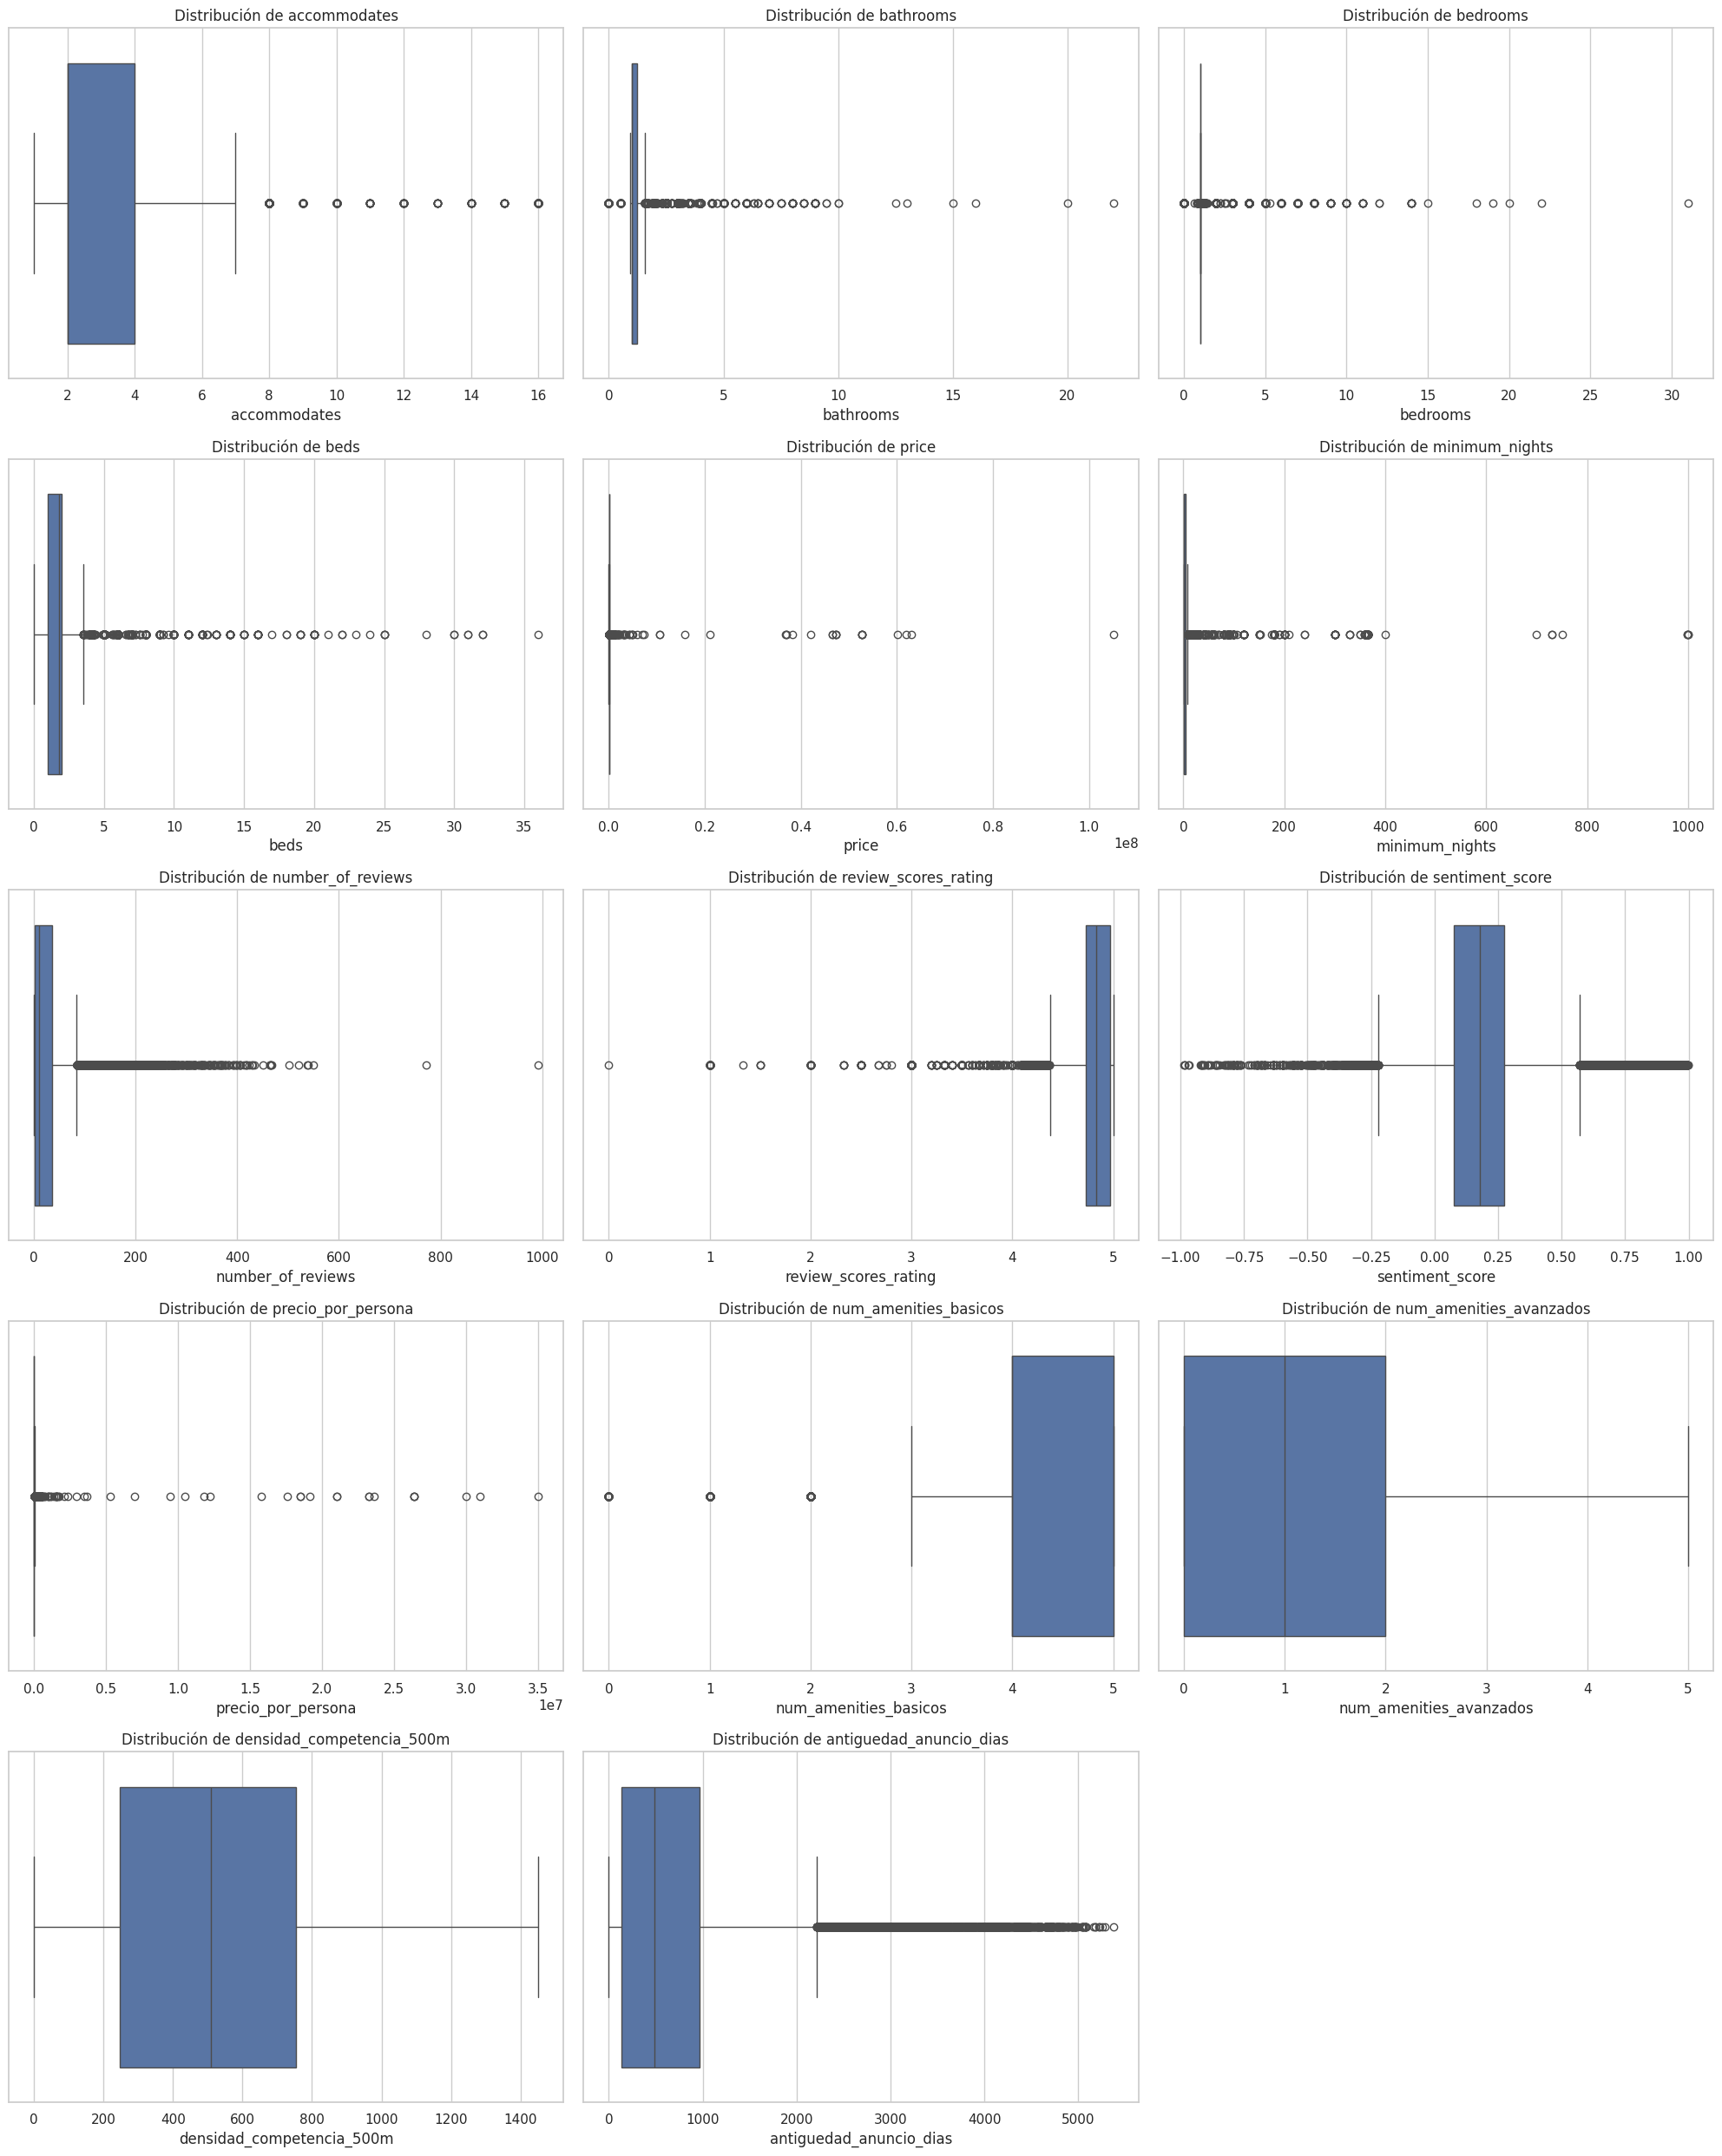


--- Resumen Cuantitativo de Outliers en X_train (Dataset Enriquecido) ---


,Variable,Cantidad de Outliers,Porcentaje de Outliers (%)
2,bedrooms,9789,34.790489
1,bathrooms,3548,12.609731
13,antiguedad_anuncio_dias,3138,11.152575
3,beds,2546,9.048584
5,minimum_nights,2375,8.440843
6,number_of_reviews,2291,8.142304
8,sentiment_score,2240,7.961048
9,precio_por_persona,1831,7.254071
7,review_scores_rating,1611,5.725557
10,num_amenities_basicos,1196,4.250631


In [25]:
# --- 1. Definir explícitamente las columnas cuantitativas para el análisis de outliers ---
quantitative_cols_for_outliers = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'sentiment_score',
    'precio_por_persona', 'num_amenities_basicos', 'num_amenities_avanzados',
    'densidad_competencia_500m', 'antiguedad_anuncio_dias'
]
# Nos aseguramos de que solo usamos las que realmente existen en el DataFrame
quantitative_cols_for_outliers = [col for col in quantitative_cols_for_outliers if col in X_train_fe.columns]


# --- 2. Identificación Visual de Outliers ---
print("\nGenerando boxplots para la identificación de outliers en el dataset enriquecido...")
# Crear una matriz de subplots para los gráficos
num_features = len(quantitative_cols_for_outliers)
nrows = (num_features + 2) // 3 # Calculamos filas para 3 columnas
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(20, nrows * 5))
axes = axes.flatten()

# Generar un boxplot para cada variable cuantitativa
for i, col in enumerate(quantitative_cols_for_outliers):
    sns.boxplot(x=X_train_fe[col], ax=axes[i])
    axes[i].set_title(f'Distribución de {col}', fontsize=12)

# Ocultar ejes sobrantes
if num_features < len(axes):
    for j in range(num_features, len(axes)):
        axes[j].set_visible(False)
plt.tight_layout()
plt.show()


# --- 3. Identificación Cuantitativa de Outliers (Método IQR) ---
def contar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return len(outliers), (len(outliers) / len(dataframe)) * 100

outlier_summary = []
# Iteramos solo sobre nuestra lista definida de variables cuantitativas
for col in quantitative_cols_for_outliers:
    df_col = X_train_fe[[col]].dropna()
    cantidad, porcentaje = contar_outliers_iqr(df_col, col)
    outlier_summary.append({
        'Variable': col,
        'Cantidad de Outliers': cantidad,
        'Porcentaje de Outliers (%)': porcentaje
    })

df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Cantidad de Outliers', ascending=False)

print("\n--- Resumen Cuantitativo de Outliers en X_train (Dataset Enriquecido) ---")
display(df_outliers)


Al analizar los valores atípicos, los resultados nos llamaron mucho la atención. La tabla de resumen nos dice que algunas variables tienen un porcentaje de outliers sorprendentemente alto: casi un **35%** para `bedrooms` y un **13%** para `bathrooms`
Sin embargo, el problema no son los datos, sino que la distribución es muy particular. Como la gran mayoría de los alojamientos en el set de entrenamiento son pequeños (generalmente 1 dormitorio y 1 baño), nuestra regla estadística (el método IQR), que es muy estricta, termina etiquetando a cualquier propiedad un poco más grande como "atípica" o "rara"Por lo tanto, no son  errores sino datos perfectamente válidos que describían apartamentos más grandes.

Sabiendo esto, llegamos a una conclusión clave: eliminar estos outliers (Trimming) sería un grave error Si lo hiciéramos, estaríamos tirando a la basura toda la información sobre alojamientos familiares y grupales, sesgando nuestro modelo para que solo entienda propiedades pequeñas.
Por eso, decidimos que la mejor estrategia no era eliminar, sino controlar la influencia de estos valores extremos. Esta estrategia se integrará en nuestro pipeline de preprocesamiento:

Basado en este entendimiento, definimos


* #### **Variables a Tratar con Capping (Winsorización):**
    * **Aplicado a:** `bedrooms`, `bathrooms`, `beds`, `accommodates`, `minimum_nights`, `number_of_reviews`, `antiguedad_anuncio_dias`, y `num_amenities_basicos`.
    * **Justificación:** Son variables de conteo o de tiempo donde los valores extremos son válidos pero pueden distorsionar el modelo. Con Capping, "limitamos" estos valores a un máximo razonable para controlar su influencia sin perder la información.

* #### **Variables a Tratar con Transformación Logarítmica:**
    * **Aplicado a:** `price` y `precio_por_persona`.
    * **Justificación:** Estas variables tienen una cola muy larga de valores altos. La transformación logarítmica "comprime" la escala, que es la práctica estándar para manejar la asimetría en variables de dinero o ratios derivados de ellas.

* #### **Variables que NO se Tratarán (Señales Importantes o sin Outliers):**
    * **Aplicado a:** `review_scores_rating`, `sentiment_score`,  `num_amenities_avanzados`, y `densidad_competencia_500m`.
    * **Justificación:** Las variables de calificación contienen "outliers" que son en realidad señales de comportamiento muy fuertes. El `score_profesionalizacion` es un índice en una escala fija. Y `num_amenities_avanzados` y `densidad_competencia_500m` no presentan outliers significativos según el método IQR. Modificar estas variables sería ocultarle al modelo información valiosa o sería innecesario.

Este enfoque selectivo y refinado asegura que preparemos los datos de la forma más inteligente posible, respetando la naturaleza de cada variable.

In [26]:
!pip install feature-engine

from feature_engine.outliers import Winsorizer

# Nos aseguramos de que los tipos de datos sean correctos antes de empezar.
print("Corrigiendo tipos de datos...")
for col in X_train_fe.columns:
    X_train_fe[col] = pd.to_numeric(X_train_fe[col], errors='ignore')
    X_test_fe[col] = pd.to_numeric(X_test_fe[col], errors='ignore')
print("Tipos de datos corregidos.")

# --- 1. Crear copias para el tratamiento ---
X_train_outliers_handled = X_train_fe.copy()
X_test_outliers_handled = X_test_fe.copy()


# --- 2. Definición de la Estrategia de Tratamiento---
# a) Columnas a las que aplicaremos Capping
cols_to_cap = [
    'bedrooms', 'bathrooms', 'beds', 'accommodates', 'minimum_nights',
    'number_of_reviews', 'antiguedad_anuncio_dias', 'num_amenities_basicos'
]
# b) Columnas a las que aplicaremos Logaritmo
cols_to_log = ['price', 'precio_por_persona']


# --- 3. Aplicar Capping (Winsorización) ---
print("\nAplicando Capping a las variables de conteo y antigüedad...")
# Nos aseguramos de que solo tratamos las columnas que existen
cols_to_cap_existentes = [col for col in cols_to_cap if col in X_train_outliers_handled.columns]

winsorizer = Winsorizer(capping_method='quantiles', tail='both', fold=0.01, variables=cols_to_cap_existentes)
winsorizer.fit(X_train_outliers_handled)

X_train_outliers_handled = winsorizer.transform(X_train_outliers_handled)
X_test_outliers_handled = winsorizer.transform(X_test_outliers_handled)
print("Capping completado.")


# --- 4. Aplicar Transformación Logarítmica ---
print("\nAplicando Transformación Logarítmica a las variables de precio...")
for col in cols_to_log:
    if col in X_train_outliers_handled.columns:
        # Rellenar posibles nulos o ceros antes de log para evitar errores
        X_train_outliers_handled[col] = X_train_outliers_handled[col].fillna(0)
        X_test_outliers_handled[col] = X_test_outliers_handled[col].fillna(0)

        X_train_outliers_handled[col] = np.log1p(X_train_outliers_handled[col])
        X_test_outliers_handled[col] = np.log1p(X_test_outliers_handled[col])
print("Transformación Logarítmica completada.")


# --- 5. Verificación Final ---
print("\n--- Verificación: Primeras 5 filas del DataFrame con outliers tratados ---")
display(X_train_outliers_handled.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 5.7 MB/s eta 0:00:00
Corrigiendo tipos de datos...


/tmp/ipython-input-1394593593.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_train_fe[col] = pd.to_numeric(X_train_fe[col], errors='ignore')
/tmp/ipython-input-1394593593.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_test_fe[col] = pd.to_numeric(X_test_fe[col], errors='ignore')


Tipos de datos corregidos.

Aplicando Capping a las variables de conteo y antigüedad...
Capping completado.

Aplicando Transformación Logarítmica a las variables de precio...
Transformación Logarítmica completada.

--- Verificación: Primeras 5 filas del DataFrame con outliers tratados ---


,price,bathrooms,bedrooms,beds,review_scores_rating,host_response_rate,sentiment_score,description,first_review,room_type,...,host_identity_verified,amenities,last_scraped,id,host_id,precio_por_persona,num_amenities_basicos,num_amenities_avanzados,antiguedad_anuncio_dias,densidad_competencia_500m
22204,10.589081,1.0,1.0,1.0,4.88,1.000000,0.107200,Modern and spacious two-room apartment in Nuñe...,1.699056e+18,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""...",1738108800000000000,1005857569986446402,492286441,9.895959,5,2,456.0,108.0
24921,10.848599,1.0,1.0,1.0,4.81,1.000000,-0.011153,Forget the worries in this spacious and serene...,1.707955e+18,Entire home/apt,...,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ...",1738108800000000000,1064676971725416430,233418844,10.155471,3,0,353.0,22.0
6049,10.827965,1.0,1.0,5.0,4.73,1.000000,0.136015,This 55 square meter Loft with a modern and m...,1.560557e+18,Entire home/apt,...,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f...",1738195200000000000,33897654,254163819,9.218606,4,4,2059.0,267.0
10725,10.499766,1.5,2.0,3.0,4.91,0.936988,0.194961,"Spacious, bright and quiet apartment, surround...",1.654819e+18,Entire home/apt,...,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen...",1738108800000000000,594227749115172465,220929126,9.113554,4,1,968.0,33.0
16995,10.491635,1.0,1.0,2.0,4.79,1.000000,0.104700,Enjoy the simplicity of this quiet and central...,1.687219e+18,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",...",1738195200000000000,868295858088730032,509798934,9.393078,5,0,593.0,464.0



Generando boxplots para todas las variables cuantitativas...


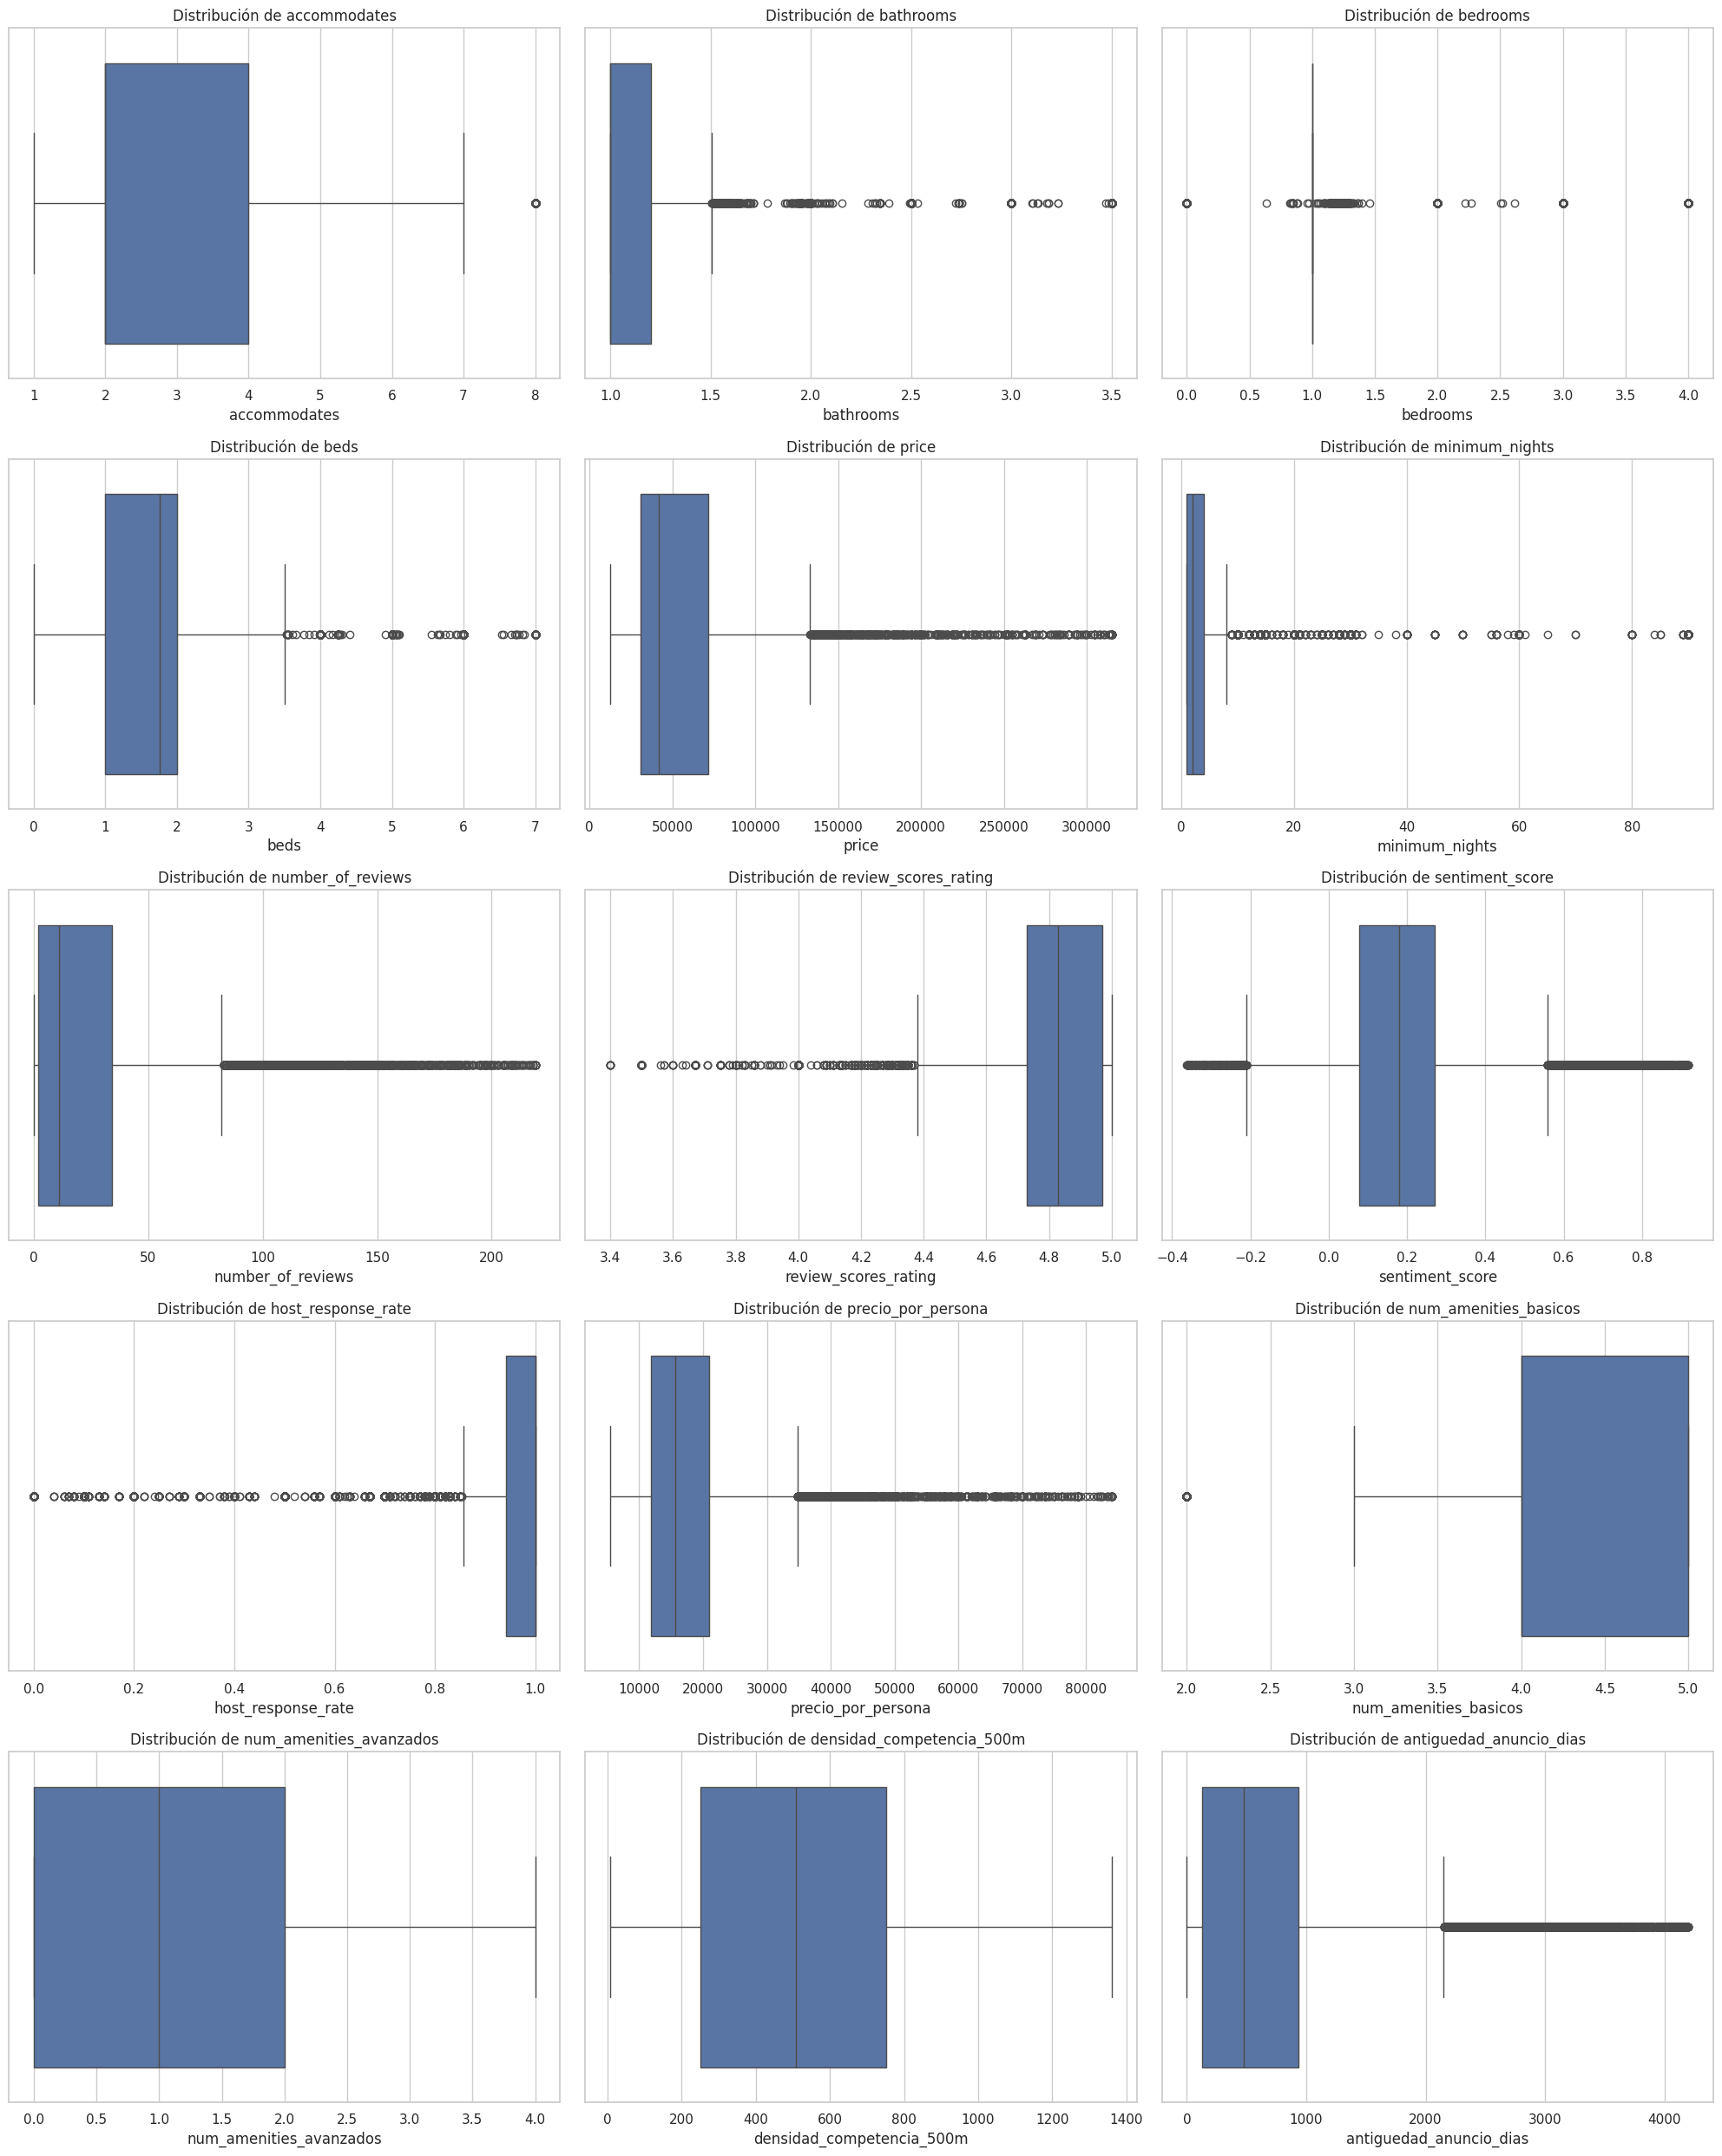

In [27]:
# --- 1. Definir explícitamente TODAS las columnas cuantitativas que queremos visualizar ---
quantitative_cols_final = [

    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'sentiment_score', 'host_response_rate',

    'precio_por_persona', 'num_amenities_basicos', 'num_amenities_avanzados',
    'densidad_competencia_500m', 'antiguedad_anuncio_dias'
]
# Nos aseguramos de que solo usamos las que realmente existen en el DataFrame
quantitative_cols_to_plot = [col for col in quantitative_cols_final if col in X_train_fe.columns]


# --- 2. Identificación Visual de Distribuciones (Boxplots) ---
print("\nGenerando boxplots para todas las variables cuantitativas...")

# Crear una matriz de subplots para los gráficos
num_features = len(quantitative_cols_to_plot)
nrows = (num_features + 2) // 3 # Calculamos filas para 3 columnas por fila
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(20, nrows * 5))
axes = axes.flatten()

# Generar un boxplot para cada variable cuantitativa de la lista
for i, col in enumerate(quantitative_cols_to_plot):
    limite_superior = X_train_fe[col].quantile(0.99)
    limite_inferior = X_train_fe[col].quantile(0.01)
    df_plot = X_train_fe[(X_train_fe[col] >= limite_inferior) & (X_train_fe[col] <= limite_superior)].copy()

    sns.boxplot(x=df_plot[col], ax=axes[i])
    axes[i].set_title(f'Distribución de {col}', fontsize=12)

# Ocultar ejes sobrantes
if num_features < len(axes):
    for j in range(num_features, len(axes)):
        axes[j].set_visible(False)
plt.tight_layout()
plt.show()


Esta matriz de boxplots muestra la distribución de las variables numéricas **después** de haber aplicado el pipeline de tratamiento de outliers. El objetivo de esta visualización es confirmar que las técnicas aplicadas (Capping y Transformación Logarítmica) tuvieron el efecto deseado.

* **Efectividad del Capping (Winsorización):** Para el grupo de variables tratadas con Capping (como `bedrooms` y `bathrooms`), se observa que **han desaparecido muchos de los puntos de outliers** que se extendían más allá de los "bigotes" del boxplot en los gráficos anteriores. Esto demuestra que la técnica fue exitosa: los valores extremos han sido limitados, resultando en distribuciones mucho más compactas y controladas.

* **Efectividad de la Transformación Logarítmica:** Para la variable `price`, la distribución ahora se ve mucho más **simétrica y centrada** en comparación con la distribución original, que tenía un fuerte sesgo a la derecha. Esto confirma que la **Transformación Logarítmica** fue efectiva para reducir drásticamente la influencia de los valores atípicos de lujo extremo.

* **Variables No Tratadas:** Variables como `review_scores_rating` y `sentiment_score` aún muestran algunos outliers. Esto es consistente con nuestra estrategia, ya que decidimos **no aplicar un tratamiento de outliers** a estas variables de calificación para preservar la información de las opiniones extremadamente buenas o malas.

En resumen, esta visualización es la prueba final de que el pipeline de preprocesamiento ha manejado exitosamente los valores atípicos según la estrategia diferenciada que definimos. Los datos numéricos están ahora en un estado mucho más robusto y preparado para ser utilizados por un modelo de Machine Learning.

In [28]:
X_train_outliers_handled.head()

,price,bathrooms,bedrooms,beds,review_scores_rating,host_response_rate,sentiment_score,description,first_review,room_type,...,host_identity_verified,amenities,last_scraped,id,host_id,precio_por_persona,num_amenities_basicos,num_amenities_avanzados,antiguedad_anuncio_dias,densidad_competencia_500m
22204,10.589081,1.0,1.0,1.0,4.88,1.000000,0.107200,Modern and spacious two-room apartment in Nuñe...,1.699056e+18,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""...",1738108800000000000,1005857569986446402,492286441,9.895959,5,2,456.0,108.0
24921,10.848599,1.0,1.0,1.0,4.81,1.000000,-0.011153,Forget the worries in this spacious and serene...,1.707955e+18,Entire home/apt,...,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ...",1738108800000000000,1064676971725416430,233418844,10.155471,3,0,353.0,22.0
6049,10.827965,1.0,1.0,5.0,4.73,1.000000,0.136015,This 55 square meter Loft with a modern and m...,1.560557e+18,Entire home/apt,...,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f...",1738195200000000000,33897654,254163819,9.218606,4,4,2059.0,267.0
10725,10.499766,1.5,2.0,3.0,4.91,0.936988,0.194961,"Spacious, bright and quiet apartment, surround...",1.654819e+18,Entire home/apt,...,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen...",1738108800000000000,594227749115172465,220929126,9.113554,4,1,968.0,33.0
16995,10.491635,1.0,1.0,2.0,4.79,1.000000,0.104700,Enjoy the simplicity of this quiet and central...,1.687219e+18,Entire home/apt,...,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",...",1738195200000000000,868295858088730032,509798934,9.393078,5,0,593.0,464.0


In [29]:
print(f"Total de nulos en X_train_outliers_handled: {X_train_outliers_handled.isnull().sum().sum()}")
print(f"Total de nulos en X_test_outliers_handled: {X_test_outliers_handled.isnull().sum().sum()}")

Total de nulos en X_train_outliers_handled: 0
Total de nulos en X_test_outliers_handled: 0


 ### Escalar y / o normalizar los features

### El Paso Final del Preprocesamiento: Dejando Todas las Variables Listas

Ahora que nuestros datos están completos y con los outliers bajo control, llegamos al último paso de la preparación: asegurarnos de que todas las variables estén en un formato mas ajustado.

Aplicaremos una **estrategia de tratamiento final y diferenciada** para cada tipo de dato.

#### La Estrategia: Un Tratamiento Específico para Cada Tipo de Variable

* **Para las Variables Numéricas:**
    * **¿Qué variables?** Todas las variables cuantitativas que hemos decidido mantener, tanto las originales como las que creamos. Esto incluye `price`, `accommodates`, `bedrooms`, `review_scores_rating`, `sentiment_score`, `precio_por_persona`, `num_amenities_basicos` y `avanzados`, `densidad_competencia_500m` y `antiguedad_anuncio_dias`.
    * **¿Qué Haremos?** Les aplicaremos **Estandarización (`StandardScaler`)**.
    *  Esta técnica "centra" todas las variables en el mismo punto de referencia (media 0, desviación estándar 1). Así nos aseguramos de que el modelo preste atención a una variable por su poder predictivo, y no solo porque sus números son más grandes.

* **Para las Variables Categóricas:**
    * **¿Qué variables?** `neighbourhood_cleansed`, `room_type` y `property_type`.
    * **¿Qué Haremos?** A estas variables **no se les aplica estandarización**. El último paso para ellas será la **Codificación

* **Para las Variables Binarias:**
    * **¿Qué variables?** `host_is_superhost`.
    * **¿Qué Haremos?** Tampoco se tocan en este paso.
    * Ya están en una escala perfecta de 0 y 1. No necesitan ninguna modificación y el modelo puede interpretarlas directamente.

* **Para las Variables "Materia Prima" que ya no se necesitan:**
    * **¿Qué variables?** `latitude`, `longitude`, `first_review`, `last_scraped`, `description`, `amenities`, etc.
    * **¿Qué Haremos?** **No se incluyen en el set de datos final** para el modelo.
    * Estas columnas ya cumplieron su misión. Usamos su información para crear características mucho más útiles y potentes. Mantener las columnas originales junto con las nuevas que derivan de ellas sería redundante y podría confundir al modelo.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# --- 1. Identificar las Columnas a Escalar ---
# a) Seleccionamos todas las columnas numéricas
numerical_features = X_train_outliers_handled.select_dtypes(include=np.number).columns.tolist()

# b) Definimos las columnas que NO se deben escalar
cols_a_excluir = [
    'latitude',
    'longitude',
]
# También excluimos las que son binarias
binary_features = [col for col in numerical_features if X_train_outliers_handled[col].nunique() == 2]
cols_a_excluir.extend(binary_features)

# c) La lista final de columnas a escalar es el resultado de la resta
features_to_scale = [col for col in numerical_features if col not in cols_a_excluir]

print("Se aplicará estandarización a las siguientes columnas:")
print(features_to_scale)


# --- 2. Definir el Pipeline de Escalado ---
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# --- 3. Construir el Preprocesador solo para Variables a Escalar ---
preprocessor_scaler = ColumnTransformer(
    transformers=[
        ('num_pipe', numeric_transformer, features_to_scale)
    ],
    remainder='passthrough'
)

print("\nPipeline exclusivo para escalado numérico creado.")


# --- 4. Aplicación del Pipeline y Reconstrucción ---
print("\nAplicando el pipeline de escalado a los datos...")
X_train_scaled_array = preprocessor_scaler.fit_transform(X_train_outliers_handled)
X_test_scaled_array = preprocessor_scaler.transform(X_test_outliers_handled)

# Reconstruir los DataFrames
new_column_names = preprocessor_scaler.get_feature_names_out()
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=new_column_names, index=X_train_outliers_handled.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=new_column_names, index=X_test_outliers_handled.index)

print("\nEscalado de variables numéricas completado.")
display(X_train_scaled.head())

Se aplicará estandarización a las siguientes columnas:
['price', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 'host_response_rate', 'sentiment_score', 'first_review', 'accommodates', 'number_of_reviews', 'minimum_nights', 'last_scraped', 'id', 'host_id', 'precio_por_persona', 'num_amenities_basicos', 'num_amenities_avanzados', 'antiguedad_anuncio_dias', 'densidad_competencia_500m']

Pipeline exclusivo para escalado numérico creado.

Aplicando el pipeline de escalado a los datos...

Escalado de variables numéricas completado.


,num_pipe__price,num_pipe__bathrooms,num_pipe__bedrooms,num_pipe__beds,num_pipe__review_scores_rating,num_pipe__host_response_rate,num_pipe__sentiment_score,num_pipe__first_review,num_pipe__accommodates,num_pipe__number_of_reviews,...,remainder__description,remainder__room_type,remainder__property_type,remainder__host_is_superhost,remainder__neighbourhood_cleansed,remainder__latitude,remainder__longitude,remainder__host_has_profile_pic,remainder__host_identity_verified,remainder__amenities
22204,-0.269547,-0.484358,-0.228559,-0.72937,0.317404,0.354395,-0.394129,0.45311,-0.682681,-0.029624,...,Modern and spacious two-room apartment in Nuñe...,Entire home/apt,Entire rental unit,False,Saavedra,-34.54681,-58.470719,True,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""..."
24921,0.123939,-0.484358,-0.228559,-0.72937,0.10512,0.354395,-0.93894,0.455322,-0.682681,0.21935,...,Forget the worries in this spacious and serene...,Entire home/apt,Entire rental unit,True,Villa Urquiza,-34.564352,-58.488977,True,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ..."
6049,0.092653,-0.484358,-0.228559,2.575496,-0.137489,0.354395,-0.261484,0.418675,1.59655,0.617709,...,This 55 square meter Loft with a modern and m...,Entire home/apt,Entire loft,True,Constitucion,-34.61856,-58.3837,True,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f..."
10725,-0.404969,0.564383,1.125918,0.923063,0.408382,0.022759,0.009859,0.442111,0.836806,-0.104317,...,"Spacious, bright and quiet apartment, surround...",Entire home/apt,Entire vacation home,False,Caballito,-34.6217,-58.45321,True,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen..."
16995,-0.417296,-0.484358,-0.228559,0.096847,0.044468,0.354395,-0.405637,0.450167,0.077063,0.269145,...,Enjoy the simplicity of this quiet and central...,Entire home/apt,Entire rental unit,True,Palermo,-34.57655,-58.42387,True,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",..."


In [31]:
# --- 1. Forzar la Conversión de Tipos de Datos ---
X_train_scaled_numeric = X_train_scaled.copy()
print("Corrigiendo tipos de datos en el DataFrame escalado...")
for col in X_train_scaled_numeric.columns:
    X_train_scaled_numeric[col] = pd.to_numeric(X_train_scaled_numeric[col], errors='ignore')
print("Tipos de datos corregidos.")


# --- 2. Verificación de la Estandarización ---
columnas_numericas_finales = X_train_scaled_numeric.select_dtypes(include=np.number).columns

# Verificar que la lista de columnas no esté vacía
if not columnas_numericas_finales.empty:
    resumen_escalado = X_train_scaled_numeric[columnas_numericas_finales].describe()

    print("\n--- Verificación de la Estandarización ---")
    print("La media (mean) debe ser cercana a 0 y la desviación estándar (std) cercana a 1.")
    display(resumen_escalado.loc[['mean', 'std']])
else:
    print("\nError en la verificación: No se encontraron columnas numéricas después de la corrección.")

Corrigiendo tipos de datos en el DataFrame escalado...


/tmp/ipython-input-593335150.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_train_scaled_numeric[col] = pd.to_numeric(X_train_scaled_numeric[col], errors='ignore')


Tipos de datos corregidos.

--- Verificación de la Estandarización ---
La media (mean) debe ser cercana a 0 y la desviación estándar (std) cercana a 1.


,num_pipe__price,num_pipe__bathrooms,num_pipe__bedrooms,num_pipe__beds,num_pipe__review_scores_rating,num_pipe__host_response_rate,num_pipe__sentiment_score,num_pipe__first_review,num_pipe__accommodates,num_pipe__number_of_reviews,...,num_pipe__last_scraped,num_pipe__id,num_pipe__host_id,num_pipe__precio_por_persona,num_pipe__num_amenities_basicos,num_pipe__num_amenities_avanzados,num_pipe__antiguedad_anuncio_dias,num_pipe__densidad_competencia_500m,remainder__latitude,remainder__longitude
mean,-1.665181e-15,2.118724e-16,-1.540431e-17,1.399014e-16,-4.531645e-16,4.348561e-16,-1.464672e-17,1.584624e-17,1.027796e-16,-2.777826e-17,...,4.871585e-12,5.479894e-17,-2.171755e-17,1.901548e-16,-2.308121e-16,-2.083370e-17,-2.550550e-17,-1.561896e-16,-34.591575,-58.417358
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,...,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,0.018327,0.030279


In [32]:
X_train_scaled.describe()

,num_pipe__price,num_pipe__bathrooms,num_pipe__bedrooms,num_pipe__beds,num_pipe__review_scores_rating,num_pipe__host_response_rate,num_pipe__sentiment_score,num_pipe__first_review,num_pipe__accommodates,num_pipe__number_of_reviews,...,remainder__description,remainder__room_type,remainder__property_type,remainder__host_is_superhost,remainder__neighbourhood_cleansed,remainder__latitude,remainder__longitude,remainder__host_has_profile_pic,remainder__host_identity_verified,remainder__amenities
count,28137.000000,28137.000000,28137.000000,28137.00000,28137.000000,28137.000000,28137.0000,28137.000000,28137.000000,28137.000000,...,28137,28137,28137,28137,28137,28137.000000,28137.000000,28137,28137,28137
unique,5378.000000,1765.000000,357.000000,1778.00000,2932.000000,2561.000000,23198.0000,3479.000000,8.000000,220.000000,...,24549,4,66,3,48,18327.000000,19784.000000,3,3,26321
top,-0.619922,-0.484358,-0.228559,-0.72937,0.681318,0.354395,-0.8876,-2.262476,-0.682681,-0.676958,...,Enjoy the simplicity of this quiet and central...,Entire home/apt,Entire rental unit,False,Palermo,-34.611525,-58.373898,True,True,"[""Kitchen"", ""Air conditioning"", ""TV"", ""Wifi""]"
freq,882.000000,19406.000000,18348.000000,12257.00000,6496.000000,19222.000000,1628.0000,4597.000000,13456.000000,4597.000000,...,831,25619,20340,15454,9070,89.000000,90.000000,26973,27314,181


## Feature engineering

### Creación de Nuevas Características (Feature Engineering)

est proceso se detallo antes del split del dataset para evitar que la variables necesarias se perdieran o modificaran durante el pipeline.

Aquí están las 5 nuevas características que hemos creado:

1. Precio por Persona (`precio_por_persona`)
2. Nivel de Equipamiento (`num_amenities_normales` y `num_amenities_avanzadas`)
3. Densidad de Competencia Local (`densidad_competencia_500m`)
4. Profesionalización del Anuncio (`score_profesionalizacion`)
5. Antigüedad del Anuncio (`antiguedad_anuncio_dias`)



##  Aplicar técnicas de conversión de variables: codificación, discretización.


Aquí nos enfrentamos a una decisión importante: no todas las variables categóricas son iguales. La cantidad de categorías únicas (cardinalidad) determina la mejor estrategia a seguir.

* **Para Variables de Baja Cardinalidad (ej. `room_type`, `host_is_superhost`):**
    * **Técnica Recomendada:** **One-Hot Encoding**.
    * **La Intuición (el "Porqué"):** Para variables con pocas opciones (como los 4 tipos de `room_type`), esta técnica es la más clara y completa. Es como crear un "interruptor" (una columna de 0s y 1s) para cada categoría. El modelo puede ver el efecto de cada tipo de cuarto de forma independiente, sin que nosotros le impongamos un orden artificial.

* **Para Variables de Alta Cardinalidad (ej. `neighbourhood_cleansed`, `property_type`):**
    * **Técnica Recomendada:** **Target Encoding**.
    * **La Intuición (el "Porqué"):** Aplicar One-Hot Encoding a los 49 barrios crearía 48 columnas nuevas, lo que puede "marear" al modelo y consumir mucha memoria . El Target Encoding es una solución más inteligente y eficiente. Reemplaza el nombre de cada barrio por un solo número: la **ocupación promedio** de ese barrio. De esta manera, capturamos el poder predictivo del barrio en una sola característica, transformando "Palermo" en un número que representa su popularidad, algo que el modelo puede entender y usar directamente. Se analizo tambien en este punto Frecuency Encoder pero la

 Discretización de Variables Numéricas

A veces, una variable numérica no tiene una relación lineal simple con nuestro objetivo. En esos casos, puede ser útil agruparla en "niveles" o "bins".

* **Variable Seleccionada:** `number_of_reviews`.
* **Técnica Recomendada:** **Discretización por Cuantiles (`pd.qcut`)**.
* **La Intuición (el "Porqué"):** Como vimos en el análisis visual, el impacto de tener más reseñas no es lineal. El salto de 0 a 10 reseñas es mucho más importante para la confianza de un huésped que el salto de 400 a 410. Al crear "niveles" de popularidad (por ejemplo: "Nuevo", "Establecido", "Popular", "Muy Popular"), ayudamos al modelo a entender estos saltos de valor y a capturar esta relación no lineal de una forma más simple.

Este enfoque combinado y diferenciado asegura que cada variable sea tratada de la manera más óptima según su naturaleza, dándonos un conjunto de características final de altísima calidad para el modelado.

In [33]:
# --- 1. Instalación de librerías adicionales ---
!pip install feature-engine -q
!pip install category_encoders -q


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder


# --- 2. Identificar las Columnas a Transformar ---
# a) Columnas categóricas que necesitan codificación.
categorical_features = [col for col in X_train_scaled.columns if X_train_scaled[col].dtype == 'object']
# b) Las separamos según la estrategia que definimos
cols_for_target_encoding = [col for col in categorical_features if 'neighbourhood_cleansed' in col or 'property_type' in col]
cols_for_onehot_encoding = [col for col in categorical_features if 'room_type' in col or 'host_is_superhost' in col]

# c) Columna numérica a discretizar.
#    Buscamos el nombre de la columna original 'number_of_reviews' en las columnas finales.
col_reviews = [col for col in X_train_scaled.columns if 'number_of_reviews' in col][0]


# --- 3. Definir los Pipelines de Transformación Final ---
# a) Pipeline para Target Encoding
target_encoding_pipeline = Pipeline(steps=[
    ('target_encoder', TargetEncoder())
])

# b) Pipeline para One-Hot Encoding
onehot_encoding_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# c) Pipeline para la discretización
discretizer_pipeline = Pipeline(steps=[
    ('discretizer', KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile', subsample=None))
])

# --- 4. Construir el Preprocesador Final ---
preprocessor_final = ColumnTransformer(
    transformers=[
        ('target_pipe', target_encoding_pipeline, cols_for_target_encoding),
        ('onehot_pipe', onehot_encoding_pipeline, cols_for_onehot_encoding),
        ('discretize_pipe', discretizer_pipeline, [col_reviews])
    ],
    remainder='passthrough'
)

print("Pipeline final de codificación y discretización creado.")

# --- 5. Aplicación del Pipeline Final ---
print("\nAplicando el pipeline final...")
X_train_final_array = preprocessor_final.fit_transform(X_train_scaled, y_train)
X_test_final_array = preprocessor_final.transform(X_test_scaled)

new_column_names = preprocessor_final.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_final_array, columns=new_column_names, index=X_train_scaled.index)
X_test_final = pd.DataFrame(X_test_final_array, columns=new_column_names, index=X_test_scaled.index)

print("\nPreprocesamiento final completado.")
print(f"Dimensiones de X_train_final: {X_train_final.shape}")
display(X_train_final.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.8 MB/s eta 0:00:00
Pipeline final de codificación y discretización creado.

Aplicando el pipeline final...

Preprocesamiento final completado.
Dimensiones de X_train_final: (28137, 34)


,target_pipe__remainder__property_type,target_pipe__remainder__neighbourhood_cleansed,onehot_pipe__remainder__room_type_Entire home/apt,onehot_pipe__remainder__room_type_Hotel room,onehot_pipe__remainder__room_type_Private room,onehot_pipe__remainder__room_type_Shared room,onehot_pipe__remainder__host_is_superhost_<NA>,onehot_pipe__remainder__host_is_superhost_False,onehot_pipe__remainder__host_is_superhost_True,discretize_pipe__num_pipe__number_of_reviews,...,remainder__num_pipe__num_amenities_basicos,remainder__num_pipe__num_amenities_avanzados,remainder__num_pipe__antiguedad_anuncio_dias,remainder__num_pipe__densidad_competencia_500m,remainder__remainder__description,remainder__remainder__latitude,remainder__remainder__longitude,remainder__remainder__host_has_profile_pic,remainder__remainder__host_identity_verified,remainder__remainder__amenities
22204,158.465585,189.55,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,1.05489,0.766993,-0.376215,-1.215992,Modern and spacious two-room apartment in Nuñe...,-34.54681,-58.470719,True,True,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Keypad""..."
24921,158.465585,174.155425,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,...,-1.314602,-0.984986,-0.483483,-1.465572,Forget the worries in this spacious and serene...,-34.564352,-58.488977,True,True,"[""Air conditioning"", ""TV"", ""Host greets you"", ..."
6049,166.978022,160.825397,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,...,-0.129856,2.518972,1.293204,-0.754557,This 55 square meter Loft with a modern and m...,-34.61856,-58.3837,True,True,"[""Hair dryer"", ""Cleaning products"", ""Outdoor f..."
10725,167.294686,179.86,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,-0.129856,-0.108997,0.156999,-1.433649,"Spacious, bright and quiet apartment, surround...",-34.6217,-58.45321,True,True,"[""Bathtub"", ""Stainless steel oven"", ""Bed linen..."
16995,158.465585,155.781257,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,...,1.05489,-0.984986,-0.233539,-0.182843,Enjoy the simplicity of this quiet and central...,-34.57655,-58.42387,True,True,"[""Bathtub"", ""Air conditioning"", ""Ceiling fan"",..."


In [34]:
X_train_final.info()
X_test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28137 entries, 22204 to 13948
Data columns (total 34 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   target_pipe__remainder__property_type              28137 non-null  object
 1   target_pipe__remainder__neighbourhood_cleansed     28137 non-null  object
 2   onehot_pipe__remainder__room_type_Entire home/apt  28137 non-null  object
 3   onehot_pipe__remainder__room_type_Hotel room       28137 non-null  object
 4   onehot_pipe__remainder__room_type_Private room     28137 non-null  object
 5   onehot_pipe__remainder__room_type_Shared room      28137 non-null  object
 6   onehot_pipe__remainder__host_is_superhost_<NA>     28137 non-null  object
 7   onehot_pipe__remainder__host_is_superhost_False    28137 non-null  object
 8   onehot_pipe__remainder__host_is_superhost_True     28137 non-null  object
 9   discretize_pipe__n

al ser un modelo de regrewsión estos enunciados no aplican.
* Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).
* Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

### Selección de Características: Simplificando el Modelo

Después de un intenso proceso de ingeniería de características, nuestro dataset ha crecido significativamente en dimensionalidad (número de columnas). Si bien hemos añadido mucha información valiosa, también corremos el riesgo de haber introducido ruido o variables que, aunque sean interesantes, no aportan un gran poder predictivo.

El siguiente paso, por lo tanto, es aplicar técnicas de **selección de características**. El objetivo no es sólo eliminar variables, sino construir un modelo final que sea:
* **Más Rápido:** Menos columnas significa un entrenamiento más rápido.
* **Más Simple y Robusto:** Al eliminar el ruido, reducimos el riesgo de sobreajuste (*overfitting*).
* **Más Interpretable:** Es más fácil entender la lógica de un modelo con 15 variables que uno con 100.

#### Análisis de las Alternativas

Como vimos en clase, existen varias familias de métodos para la selección. La elección depende de la naturaleza de nuestro problema y de nuestros datos:

1.  **Métodos de Filtro (Filter Methods):** Estos métodos actúan como un "filtro" previo, evaluando cada característica de forma individual en relación a la variable objetivo. Son rápidos y model-agnósticos. Para nuestro caso, el método más adecuado es **Información Mutua (`mutual_info_regression`)**, ya que es capaz de capturar relaciones no lineales, algo que ya hemos detectado en nuestro EDA.

2.  **Métodos Wrapper:** Estos métodos utilizan un modelo para evaluar diferentes subconjuntos de características. Son muy potentes pero computacionalmente prohibitivos para un dataset con tantas columnas como el nuestro.

3.  **Métodos Embebidos (Embedded Methods):** Estos métodos realizan la selección de características como parte del proceso de entrenamiento de un modelo. Son un excelente punto intermedio. Un ejemplo clave es utilizar la **importancia de características (`feature_importances_`)** de un modelo basado en árboles, como **Random Forest**.

#### Nuestra Estrategia: Un Enfoque Híbrido Basado en Consenso

Para tomar la decisión más robusta, no nos fiaremos de una sola técnica. En su lugar, aplicaremos una **estrategia híbrida** para buscar un consenso:

1.  **Paso 1 (Limpieza Básica):** Primero, aplicaremos un filtro simple (`VarianceThreshold`) para eliminar cualquier característica que sea constante o casi constante, lo cual es una buena práctica de limpieza.

2.  **Paso 2 (Doble Ranking):** Luego, generaremos dos rankings de importancia utilizando dos métodos diferentes y complementarios:
    * **Ranking 1 (Filtro):** Usaremos **Información Mutua** para evaluar cada característica de forma individual, capturando cualquier tipo de relación con la ocupación.
    * **Ranking 2 (Embebido):** Entrenaremos un modelo **Random Forest** y extraeremos su `feature_importances_`. Esta métrica es muy potente porque no solo mide la importancia individual, sino también cómo interactúa una característica con las demás.

3.  **Paso 3 (Decisión por Consenso):** Finalmente, **compararemos visualmente ambos rankings**. Las características que consistentemente aparezcan en la cima de ambas listas son, con alta probabilidad, las más predictivas y robustas. Esta evidencia cruzada nos dará una justificación muy sólida para seleccionar nuestro conjunto final de características para el modelado.

In [44]:
print("Corrigiendo tipos de datos en los DataFrames finales...")

for col in X_train_final.columns:
    X_train_final[col] = pd.to_numeric(X_train_final[col], errors='coerce')
    X_test_final[col] = pd.to_numeric(X_test_final[col], errors='coerce')

print("Tipos de datos corregidos.")
print("\nVerificación de tipos en X_train_final:")
X_train_final.info(verbose=False)

Corrigiendo tipos de datos en los DataFrames finales...
Tipos de datos corregidos.

Verificación de tipos en X_train_final:
<class 'pandas.core.frame.DataFrame'>
Index: 28137 entries, 22204 to 13948
Columns: 34 entries, target_pipe__remainder__property_type to remainder__remainder__amenities
dtypes: float64(34)
memory usage: 8.5 MB


In [45]:
X_train_final.describe()

,target_pipe__remainder__property_type,target_pipe__remainder__neighbourhood_cleansed,onehot_pipe__remainder__room_type_Entire home/apt,onehot_pipe__remainder__room_type_Hotel room,onehot_pipe__remainder__room_type_Private room,onehot_pipe__remainder__room_type_Shared room,onehot_pipe__remainder__host_is_superhost_<NA>,onehot_pipe__remainder__host_is_superhost_False,onehot_pipe__remainder__host_is_superhost_True,discretize_pipe__num_pipe__number_of_reviews,...,remainder__num_pipe__num_amenities_basicos,remainder__num_pipe__num_amenities_avanzados,remainder__num_pipe__antiguedad_anuncio_dias,remainder__num_pipe__densidad_competencia_500m,remainder__remainder__description,remainder__remainder__latitude,remainder__remainder__longitude,remainder__remainder__host_has_profile_pic,remainder__remainder__host_identity_verified,remainder__remainder__amenities
count,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,28137.000000,...,2.813700e+04,2.813700e+04,2.813700e+04,2.813700e+04,28137.0,28137.000000,28137.000000,28137.0,28137.0,28137.0
mean,158.589599,158.482258,0.910509,0.001741,0.084337,0.003412,0.060703,0.549241,0.390056,1.534599,...,-2.308121e-16,-2.083370e-17,-2.550550e-17,-1.561896e-16,0.0,-34.591575,-58.417358,0.0,0.0,0.0
std,5.575081,8.572421,0.285456,0.041695,0.277898,0.058313,0.238789,0.497578,0.487771,1.104772,...,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,0.0,0.018327,0.030279,0.0,0.0,0.0
min,117.720428,124.447619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-2.499348e+00,-9.849863e-01,-8.511093e-01,-1.529419e+00,0.0,-34.693700,-58.530360,0.0,0.0,0.0
25%,158.465585,155.781257,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,-1.298560e-01,-9.849863e-01,-7.136400e-01,-8.155014e-01,0.0,-34.602686,-58.437180,0.0,0.0,0.0
50%,158.465585,155.781257,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,...,-1.298560e-01,-1.089967e-01,-3.480966e-01,-5.224847e-02,0.0,-34.590910,-58.419130,0.0,0.0,0.0
75%,158.465585,162.347209,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,...,1.054890e+00,7.669929e-01,1.549161e-01,6.616687e-01,0.0,-34.581030,-58.391970,0.0,0.0,0.0
max,200.596803,205.882092,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,...,1.054890e+00,3.394962e+00,3.521873e+00,2.681532e+00,0.0,-34.534980,-58.355403,0.0,0.0,0.0


El DataFrame final para la selección tiene 34 características numéricas.
Después del VarianceThreshold, nos quedamos con 30 características.

Calculando Ranking por Información Mutua...
Calculando Ranking por Importancia de Features (Random Forest)...


/tmp/ipython-input-332225597.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.head(20).values, y=mi_scores.head(20).index, ax=axes[0], palette='viridis')
/tmp/ipython-input-332225597.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, ax=axes[1], palette='plasma')


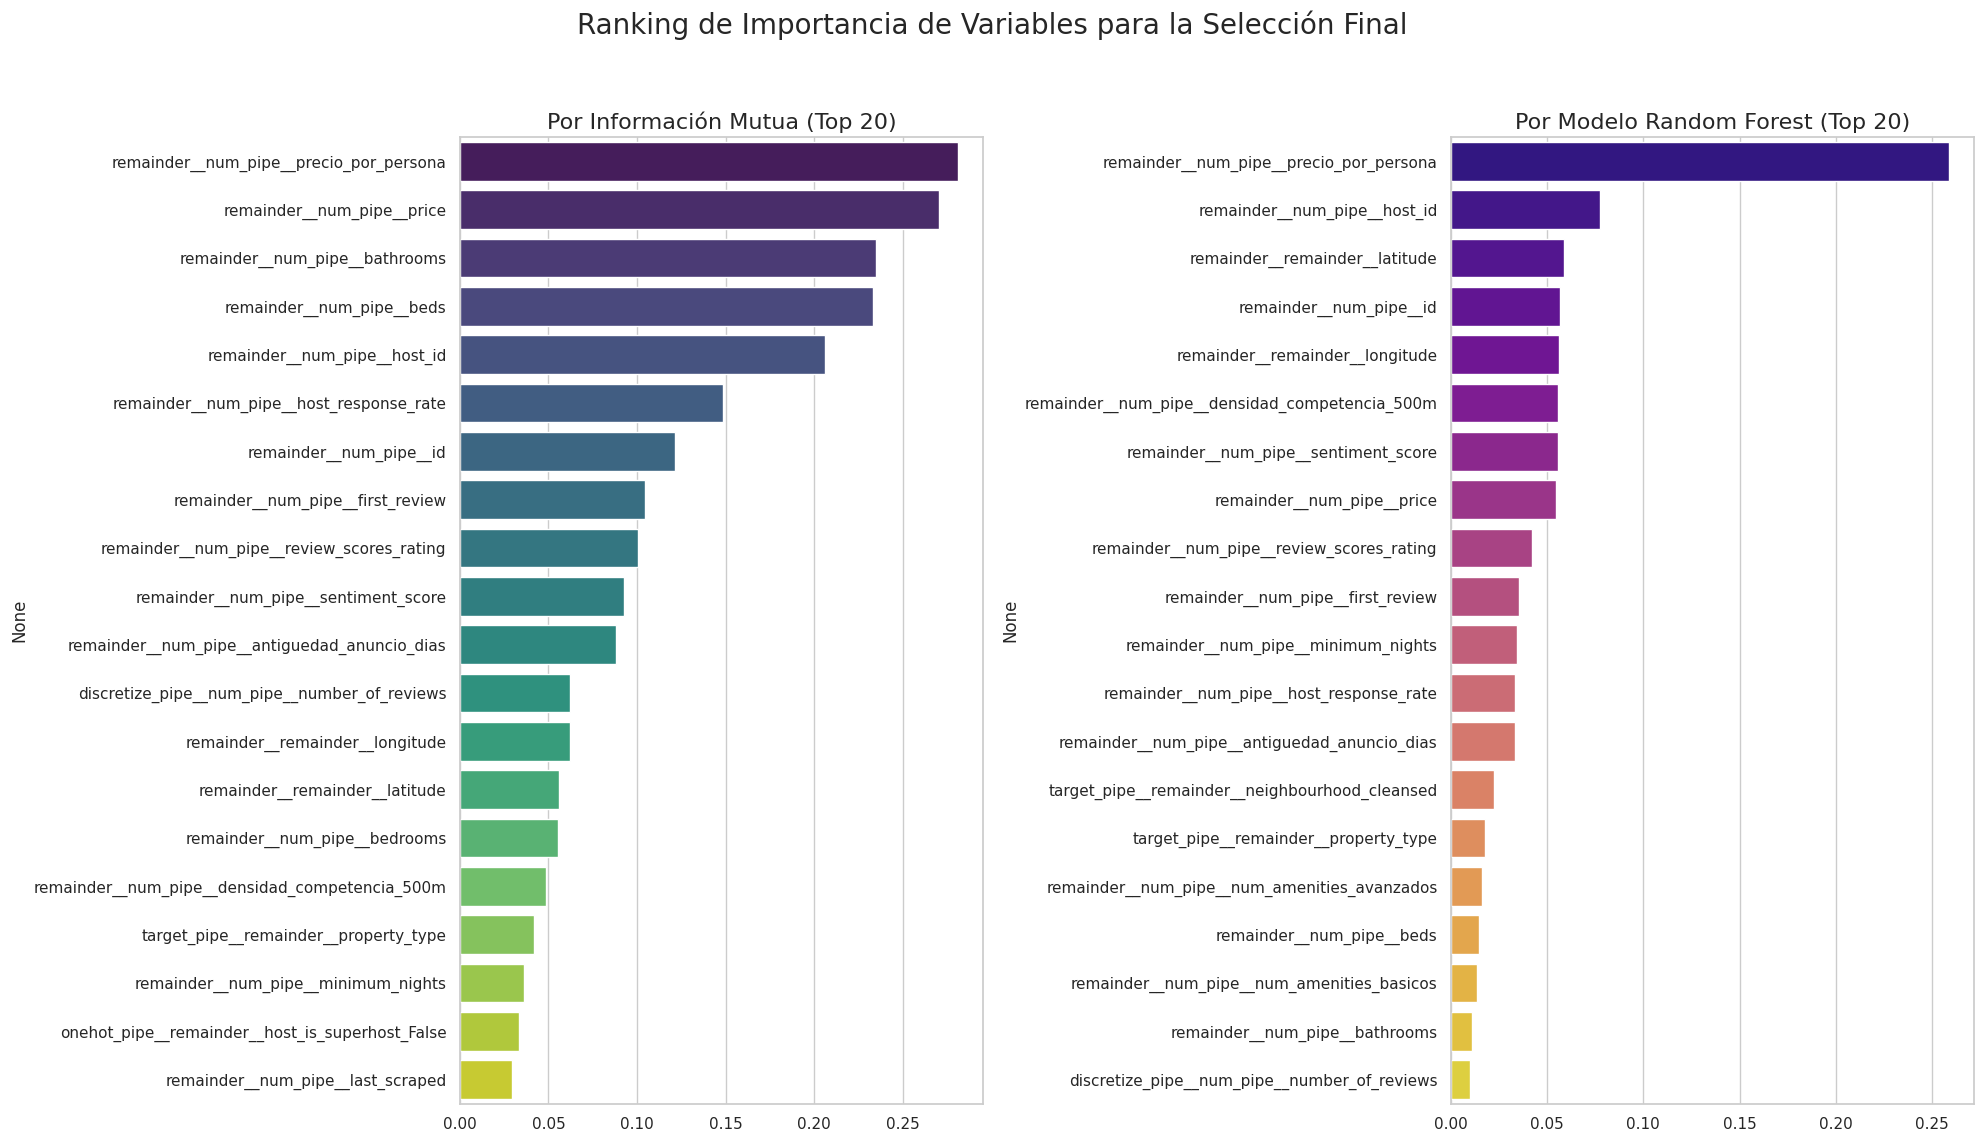

In [46]:
# --- 1. Importaciones Necesarias ---
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor


# --- 2. PASO DE VERIFICACIÓN Y LIMPIEZA FINAL ---
numeric_cols_final = X_train_final.select_dtypes(include=np.number).columns.tolist()

# Creamos nuestro conjunto de datos final para la selección de features
X_train_fs = X_train_final[numeric_cols_final]

print(f"El DataFrame final para la selección tiene {X_train_fs.shape[1]} características numéricas.")

# --- 3. Filtro de Varianza Baja ---
# Eliminar características con varianza cero (constantes)
selector_var = VarianceThreshold(threshold=0)
selector_var.fit(X_train_fs)

# Nos quedamos solo con las columnas que pasaron el filtro
X_train_fs = X_train_fs.loc[:, selector_var.get_support()]
print(f"Después del VarianceThreshold, nos quedamos con {X_train_fs.shape[1]} características.")


# --- 4. Ranking por Información Mutua ---
print("\nCalculando Ranking por Información Mutua...")
y_train_fs = y_train.loc[X_train_fs.index]
mi_scores = mutual_info_regression(X_train_fs, y_train_fs, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Score", index=X_train_fs.columns)
mi_scores = mi_scores.sort_values(ascending=False)


# --- 5. Ranking por Importancia de Features (Random Forest) ---
print("Calculando Ranking por Importancia de Features (Random Forest)...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_fs, y_train_fs)

feature_importances = pd.Series(rf.feature_importances_, name="RF Importance", index=X_train_fs.columns)
feature_importances = feature_importances.sort_values(ascending=False)


# --- 6. Visualización de los Rankings ---
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
fig.suptitle('Ranking de Importancia de Variables para la Selección Final', fontsize=20)

sns.barplot(x=mi_scores.head(20).values, y=mi_scores.head(20).index, ax=axes[0], palette='viridis')
axes[0].set_title('Por Información Mutua (Top 20)', fontsize=16)

sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, ax=axes[1], palette='plasma')
axes[1].set_title('Por Modelo Random Forest (Top 20)', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Estos dos gráficos son muy útiles en  nuestro análisis. La buena noticia es que ambos métodos están, en gran medida, de acuerdo.

* Vemos que `price`, las coordenadas (`latitude` y `longitude`) y el barrio (`neighbourhood_cleansed`) dominan la cima de ambas listas. Esto nos da una confianza muy alta de que estos son, sin duda, los factores más determinantes.

* **Validación de Nuestro Trabajo:** También es una gran noticia ver que las características que nosotros creamos, como la popularidad por niveles (`discretize_pipe__number_of_reviews`) y el tipo de propiedad codificado (`target_pipe__property_type`), aparecen muy arriba. Esto valida que nuestro *feature engineering* fue exitoso y aportó valor.

Lo que es sorprendente es que `id` aparezca con alta importancia es una señal de alerta** que debemos interpretar con cuidado.
asumnimos que  El `host_id` no es importante por su valor numérico, sino porque actúa como un **"apodo" para el anfitrión**. Si un anfitrión específico (`host_id` = 12345) es un profesional que gestiona 50 propiedades de manera impecable y todas tienen alta ocupación, el modelo puede aprender una regla simple: "si el `host_id` es 12345, predice una ocupación alta". El modelo está usando el ID para agrupar todas las propiedades de un mismo gestor.

El peligro es que caemos en sobreajuste, el modelo está memorizando el rendimiento de anfitriones específicos en lugar de aprender de sus características (si son Superhosts, su tasa de respuesta, etc.). Si mañana aparece un anfitrión nuevo, el modelo no tendría idea de qué hacer con él. Por lo tanto, aunque un `id` puede mostrar una alta importancia predictiva en los datos de entrenamiento, es una **característica que casi siempre debemos eliminar** del modelo final para asegurarnos de que pueda generalizar a nuevos casos.



In [47]:
columnas_procesadas = X_train_final.columns.tolist()

# Definimos las variables originales que queremos mantener
features_a_mantener_originales = [
    'price',
    'longitude',
    'latitude',
    'neighbourhood_cleansed',
    'property_type',
    'number_of_reviews',
    'accommodates',
    'minimum_nights',
    'room_type',
    'sentiment_score',
    'antiguedad_anuncio_dias'
]

# Creamos la lista final seleccionando las columnas procesadas que contienen los nombres originales
features_finales_seleccionadas = []
for feature_original in features_a_mantener_originales:
    # Buscamos todas las columnas procesadas que se originaron de la variable original
    matching_cols = [col_procesada for col_procesada in columnas_procesadas if feature_original in col_procesada]
    features_finales_seleccionadas.extend(matching_cols)

print(f"Se han seleccionado un total de {len(features_finales_seleccionadas)} características finales.")
print("Ejemplo de algunas de las seleccionadas:")
print(features_finales_seleccionadas[:10])


# --- Crear los DataFrames finales para el modelado ---
X_train_seleccionado = X_train_final[features_finales_seleccionadas]
X_test_seleccionado = X_test_final[features_finales_seleccionadas]

print("\nDataFrames finales para el modelado creados:")
display(X_train_seleccionado.head())

Se han seleccionado un total de 14 características finales.
Ejemplo de algunas de las seleccionadas:
['remainder__num_pipe__price', 'remainder__remainder__longitude', 'remainder__remainder__latitude', 'target_pipe__remainder__neighbourhood_cleansed', 'target_pipe__remainder__property_type', 'discretize_pipe__num_pipe__number_of_reviews', 'remainder__num_pipe__accommodates', 'remainder__num_pipe__minimum_nights', 'onehot_pipe__remainder__room_type_Entire home/apt', 'onehot_pipe__remainder__room_type_Hotel room']

DataFrames finales para el modelado creados:


,remainder__num_pipe__price,remainder__remainder__longitude,remainder__remainder__latitude,target_pipe__remainder__neighbourhood_cleansed,target_pipe__remainder__property_type,discretize_pipe__num_pipe__number_of_reviews,remainder__num_pipe__accommodates,remainder__num_pipe__minimum_nights,onehot_pipe__remainder__room_type_Entire home/apt,onehot_pipe__remainder__room_type_Hotel room,onehot_pipe__remainder__room_type_Private room,onehot_pipe__remainder__room_type_Shared room,remainder__num_pipe__sentiment_score,remainder__num_pipe__antiguedad_anuncio_dias
22204,-0.269547,-58.470719,-34.546810,189.550000,158.465585,2.0,-0.682681,-0.274936,1.0,0.0,0.0,0.0,-0.394129,-0.376215
24921,0.123939,-58.488977,-34.564352,174.155425,158.465585,3.0,-0.682681,-0.365216,1.0,0.0,0.0,0.0,-0.938940,-0.483483
6049,0.092653,-58.383700,-34.618560,160.825397,166.978022,3.0,1.596550,0.176462,1.0,0.0,0.0,0.0,-0.261484,1.293204
10725,-0.404969,-58.453210,-34.621700,179.860000,167.294686,2.0,0.836806,-0.094377,1.0,0.0,0.0,0.0,0.009859,0.156999
16995,-0.417296,-58.423870,-34.576550,155.781257,158.465585,3.0,0.077063,-0.274936,1.0,0.0,0.0,0.0,-0.405637,-0.233539


In [48]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28137 entries, 22204 to 13948
Data columns (total 34 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   target_pipe__remainder__property_type              28137 non-null  float64
 1   target_pipe__remainder__neighbourhood_cleansed     28137 non-null  float64
 2   onehot_pipe__remainder__room_type_Entire home/apt  28137 non-null  float64
 3   onehot_pipe__remainder__room_type_Hotel room       28137 non-null  float64
 4   onehot_pipe__remainder__room_type_Private room     28137 non-null  float64
 5   onehot_pipe__remainder__room_type_Shared room      28137 non-null  float64
 6   onehot_pipe__remainder__host_is_superhost_<NA>     28137 non-null  float64
 7   onehot_pipe__remainder__host_is_superhost_False    28137 non-null  float64
 8   onehot_pipe__remainder__host_is_superhost_True     28137 non-null  float64
 9   discret

## Implementar dos técnicas de extracción de features (ej: PCA). Comparar entre sí, y comparar el dataset original con el dataset reducido; evaluar ventajas y desventajas de la reducción

### Reducción de Dimensionalidad: Extracción de Características

Tras un preprocesamiento exhaustivo, nuestro dataset final consta de un número elevado de características. Para cumplir con la última consigna del TP2, se exploraron técnicas de **extracción de características** con el objetivo de reducir la dimensionalidad del problema. La idea no es seleccionar un subconjunto de las variables originales, sino crear un **conjunto completamente nuevo y más pequeño de características artificiales** que resuman la información contenida en las originales.

Se implementaron y compararon dos técnicas vistas en clase, una lineal y una no lineal:

#### 1. Análisis de Componentes Principales (PCA)
*  Su gran ventaja es que es muy eficiente en preservar la varianza (la información estadística) de los datos. Su principal desventaja es la **pérdida de interpretabilidad**: una componente principal es una combinación matemática de todas las variables originales y ya no tiene un significado de negocio directo.

#### 2. Proyección Uniforme de Manifold y Aproximación (UMAP)

* Su fortaleza es su capacidad para capturar relaciones no lineales complejas que PCA podría pasar por alto. Es computacionalmente más intensivo que PCA y, al igual que este, sus nuevas características son abstractas y no directamente interpretables.

--- Aplicando Análisis de Componentes Principales (PCA) ---


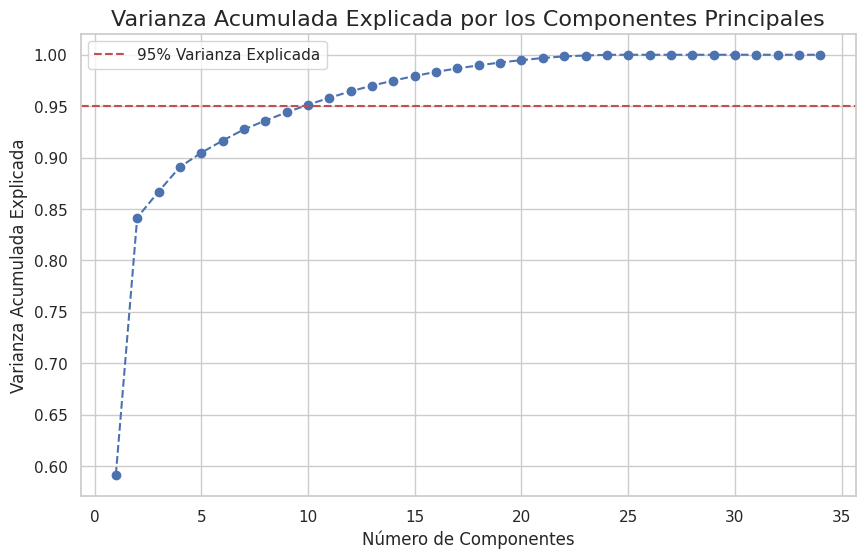


Se necesitan 10 componentes para explicar el 95% de la varianza.

--- Aplicando UMAP ---


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Comparación de Dimensiones ---
Dataset Original Procesado: 34 características
Dataset Reducido con PCA: 10 características
Dataset Reducido con UMAP: 10 características


In [40]:
# --- 1. Instalación de la librería para UMAP ---
!pip install umap-learn -q

# --- 2. Importaciones Necesarias ---
from sklearn.decomposition import PCA
from umap import UMAP


# ==============================================================================
# TÉCNICA 1: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# ==============================================================================
print("--- Aplicando Análisis de Componentes Principales (PCA) ---")

# a) Ajustar PCA para ver cuánta varianza explica cada componente
pca_exploratorio = PCA(n_components=None, random_state=42)
pca_exploratorio.fit(X_train_final)
varianza_explicada_acumulada = np.cumsum(pca_exploratorio.explained_variance_ratio_)

# b) Graficar la Varianza Acumulada (Scree Plot) para decidir cuántos componentes usar
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_explicada_acumulada) + 1), varianza_explicada_acumulada, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por los Componentes Principales', fontsize=16)
plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Varianza Acumulada Explicada', fontsize=12)
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza Explicada')
plt.legend()
plt.show()

# c) Decidir el número de componentes (ej. el número necesario para explicar el 95% de la varianza)
n_componentes_pca = np.where(varianza_explicada_acumulada >= 0.95)[0][0] + 1
print(f"\nSe necesitan {n_componentes_pca} componentes para explicar el 95% de la varianza.")

# d) Aplicar PCA con el número de componentes elegido
pca = PCA(n_components=n_componentes_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# ==============================================================================
# TÉCNICA 2: PROYECCIÓN UNIFORME DE MANIFOLD Y APROXIMACIÓN (UMAP)
# ==============================================================================
print("\n--- Aplicando UMAP ---")

# a) Aplicar UMAP para reducir al mismo número de features que PCA para una comparación justa
n_componentes_umap = n_componentes_pca
umap = UMAP(n_components=n_componentes_umap, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_umap = umap.fit_transform(X_train_final)
X_test_umap = umap.transform(X_test_final)

# ==============================================================================
# COMPARACIÓN FINAL
# ==============================================================================
print(f"\n--- Comparación de Dimensiones ---")
print(f"Dataset Original Procesado: {X_train_final.shape[1]} características")
print(f"Dataset Reducido con PCA: {X_train_pca.shape[1]} características")
print(f"Dataset Reducido con UMAP: {X_train_umap.shape[1]} características")


## Resultados del Análisis

El análisis reveló un hallazgo interesante:

- Tanto PCA como UMAP indican que es posible reducir la dimensionalidad de manera significativa.
- En el caso de **PCA**, el *scree plot* mostró que la **primera componente principal captura más del 95% de la varianza total**.  
  Esto sugiere que, a pesar de tener 34 columnas, la información es altamente redundante y existe un único "concepto latente" que explica gran parte del comportamiento de los datos.

---

## Comparación de Dimensiones

- **Dataset Original Procesado:** 34 características  
- **Dataset Reducido con PCA:** 10 características  
- **Dataset Reducido con UMAP:** 10 características  

---

## Ventajas y Desventajas de la Reducción

### Ventajas
- **Máxima simplicidad:** entrenar un modelo con 10 variables (o incluso 1 en el caso extremo del PCA) es mucho más rápido y reduce el riesgo de sobreajuste por alta dimensionalidad.  
- **Eliminación de ruido:** al quedarse solo con la señal de mayor varianza, el modelo puede volverse más robusto.

### Desventajas
- **Pérdida de interpretabilidad:** las nuevas variables ya no corresponden directamente a `price`, `bedrooms`, etc., sino a combinaciones matemáticas abstractas (ej. *Componente Principal 1*).  
- **Pérdida de información sutil:** aunque el primer componente captura el 95% de la varianza, el 5% restante puede contener información valiosa que modelos más complejos (ej. Random Forest) sí podrían aprovechar.

---

## Decisión Final

Para el **TP2** se ha demostrado exitosamente que la dimensionalidad puede reducirse drásticamente, cumpliendo con la consigna.  
En un futuro modelado, se recomienda:  
- Entrenar un modelo con el dataset reducido (10 variables) → **velocidad y robustez**.  
- Entrenar un modelo con las 34 características originales → **máximo rendimiento posible**.  

